# Class 08: Network Reconstruction from Dynamical Data


In many network-science problems, the network is not the object we observe directly. What we observe instead are node states, events, cascades, or time series, and the graph is the hidden object shaping those observations. Today's class treats **network reconstruction** as an inverse problem: a network produces data, and we ask whether the data are informative enough to recover the network.

This topic connects directly to earlier parts of the course. From Class 02, we already know that thresholding and sparsification are delicate. From Class 03 and Class 07, we saw that inference depends on assumptions and that regression/classification tools can be used to recover hidden structure. Network reconstruction sits right at that intersection.

Goals of today's class:
1. See how simple dynamics on a graph generate multivariate data.
2. Work through the Ising model on a random network and visualize its time series with `imshow`.
3. Define carefully what network reconstruction is trying to infer.
4. Compare a few reconstruction baselines and evaluation strategies.
5. Understand why many methods return scores that still need thresholding, linking back to Class 02.

This notebook contains more material than will fit in one meeting. The lecture core is the warm-up, Sections 1-8, and the thresholding discussion in Section 10. Later sections and appendices extend the topic for deeper study.
__________


![](images/recon.png)

____
We will first go in the forward direction. We start from a known graph, simulate dynamics on it, and look carefully at the data that come out. Then we reverse the arrow: we pretend the graph is hidden and ask how much of it can be recovered from the observations alone.


## Notation and conventions

We will mostly work with simple, undirected graphs:

- $G = (V, E)$ is a graph with $n = |V|$ nodes and $m = |E|$ edges.
- $A \in \{0,1\}^{n \times n}$ is the adjacency matrix, with $A_{ij}=1$ if $(i,j)\in E$ and $A_{ii}=0$.
- A time-series observation is a matrix $X \in \mathbb{R}^{T \times n}$ where $X_{t,i}$ is the state of node $i$ at time $t$.
- Many dynamics here are approximately Markov: $X_{t+1}$ depends on $X_t$ and the network.

Throughout, we distinguish between two related but different objects:

- an **edge-score matrix** $S \in \mathbb{R}^{n \times n}$, where larger values suggest more evidence for an edge, and
- a **reconstructed adjacency** $\hat A$, obtained by thresholding scores, fixing a target density, or selecting the top-$k$ pairs.

That distinction matters. Much of the notebook is really about learning how to go from observations to scores, and only then deciding how aggressively to turn scores into a graph.


In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import sklearn

from scipy import sparse
from scipy.stats import norm

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.covariance import GraphicalLasso
from sklearn.exceptions import ConvergenceWarning

print("Imports complete.")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("NetworkX:", nx.__version__)
print("scikit-learn:", sklearn.__version__)

Imports complete.
NumPy: 1.26.4
pandas: 3.0.1
NetworkX: 3.6.1
scikit-learn: 1.8.0


In [2]:
# Keep notebook output focused on reconstruction rather than library deprecation chatter.
warnings.filterwarnings(
    "ignore",
    message=".*'penalty' was deprecated.*",
    category=FutureWarning,
    module=r"sklearn\.linear_model\._logistic",
)
warnings.filterwarnings(
    "ignore",
    message="Inconsistent.*",
    category=UserWarning,
    module=r"sklearn\.linear_model\._logistic",
)


def make_rng(seed):
    """Return a NumPy random number generator from an integer seed.

    We use NumPy's `default_rng`, which is the recommended RNG interface.
    """
    return np.random.default_rng(int(seed))


def new_fig(figsize=(6, 4), dpi=100):
    """Create a Matplotlib figure with a single Axes.

    This notebook uses the `fig, ax = plt.subplots(1, 1, ...)` style everywhere
    for consistency and reproducibility.

    Parameters
    ----------
    figsize : tuple
        Figure size in inches, e.g. (6, 4).
    dpi : int
        Dots per inch.

    Returns
    -------
    fig, ax
        Matplotlib Figure and Axes.
    """
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    return fig, ax


from matplotlib import rc
rc('axes', axisbelow=True)
rc('axes', fc='w')
rc('figure', fc='w')
rc('savefig', fc='w')

DPI = 200


## A warm-up: simple dynamics on complex networks

Before doing any inference, it helps to go in the forward direction first. We start with a known graph, run dynamics on it, and inspect the data that come out. This makes the reconstruction problem specific: we are not inferring edges out of nowhere, we are trying to invert a data-generating process.

It also forces us to ask a question that will keep coming back all class: **is the data actually informative about the graph?** If the dynamics is too noisy, too frozen, too close to consensus, or too poorly observed, then recovery can fail no matter how clever the estimator is.

We begin with a very simple averaging process and then move to the Ising model, which gives us a clean binary-state example on a random network.


### Simple linear diffusion / averaging on a graph

Let $x_i(t)$ be the state of node $i$ at time $t$. A very simple update rule is

$$
x_i(t+1) = (1-\alpha)\,x_i(t) + \alpha\,\frac{1}{d_i}\sum_j A_{ij}x_j(t) + \epsilon_i(t).
$$

Here:

- $A_{ij}$ is the adjacency matrix entry telling us whether $i$ and $j$ are connected,
- $d_i = \sum_j A_{ij}$ is the degree of node $i$,
- $\frac{1}{d_i}\sum_j A_{ij}x_j(t)$ is the average state of node $i$'s neighbors,
- $\alpha \in [0,1]$ controls how strongly node $i$ listens to its neighbors, and
- $\epsilon_i(t)$ is a noise term.

Why does this form make sense? The first term keeps memory of the current state, the second term pulls the node toward its neighborhood average, and the noise term keeps the system from collapsing too quickly to a perfectly flat consensus.

In the code below:

- `x_t[i]` stores $x_i(t)$,
- `A_toy` stores $A$,
- `degrees[i]` stores $d_i$,
- `alpha` stores $\alpha$, and
- `noise[i]` stores one realization of $\epsilon_i(t)$.


In [3]:
# A one-step numerical example of linear diffusion on a tiny graph

A_toy = np.array([
    [0, 1, 0, 0],
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [0, 0, 1, 0],
], dtype=float)

x_t = np.array([1.0, -0.5, 0.75, -1.25])
alpha = 0.4
noise = np.array([0.00, 0.05, -0.02, 0.01])

degrees = A_toy.sum(axis=1)
neighbor_average = np.divide(A_toy @ x_t, degrees, out=np.zeros_like(x_t), where=degrees > 0)
x_next = (1 - alpha) * x_t + alpha * neighbor_average + noise

print("x(t)             =", np.round(x_t, 3))
print("neighbor average =", np.round(neighbor_average, 3))
print("noise            =", np.round(noise, 3))
print("x(t+1)           =", np.round(x_next, 3))

x(t)             = [ 1.   -0.5   0.75 -1.25]
neighbor average = [-0.5    0.875 -0.875  0.75 ]
noise            = [ 0.    0.05 -0.02  0.01]
x(t+1)           = [ 0.4   0.1   0.08 -0.44]


In [4]:
def largest_component_demo(G):
    """Return the largest connected component relabeled to 0..n-1."""
    if G.number_of_nodes() == 0:
        return G.copy()
    if not nx.is_connected(G):
        comp = max(nx.connected_components(G), key=len)
        G = G.subgraph(comp).copy()
    return nx.convert_node_labels_to_integers(G, first_label=0)


def simulate_linear_average_demo(G, T=80, alpha=0.35, noise_std=0.08, rng_seed=0):
    """Simulate a simple noisy averaging process on a graph.

    Parameters
    ----------
    G : networkx.Graph
        Undirected graph.
    T : int
        Number of recorded time steps.
    alpha : float
        Weight given to the neighbor average at each step.
    noise_std : float
        Standard deviation of the additive noise term.
    rng_seed : int
        Random seed.

    Returns
    -------
    X : ndarray, shape (T, n)
        Matrix of node states through time.
    """
    rng = make_rng(rng_seed)
    n = G.number_of_nodes()
    A = nx.to_numpy_array(G, dtype=float)
    degrees = A.sum(axis=1)
    W = np.divide(A, degrees[:, None], out=np.zeros_like(A), where=degrees[:, None] > 0)

    X = np.zeros((T, n), dtype=float)
    X[0] = rng.normal(size=n)

    for t in range(T - 1):
        X[t + 1] = (1 - alpha) * X[t] + alpha * (W @ X[t]) + noise_std * rng.normal(size=n)

    return X

In [5]:
G_linear_demo = largest_component_demo(nx.erdos_renyi_graph(30, 0.12, seed=12))
pos_linear_demo = nx.spring_layout(G_linear_demo, seed=12)
X_linear_demo = simulate_linear_average_demo(G_linear_demo, T=90, alpha=0.35, noise_std=0.06, rng_seed=13)

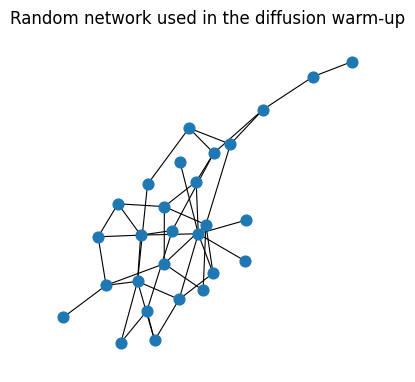

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5), dpi=100)
nx.draw_networkx(G_linear_demo, pos=pos_linear_demo, ax=ax, node_size=60, with_labels=False, width=0.8)
ax.set_title("Random network used in the diffusion warm-up")
ax.set_axis_off()
plt.show()

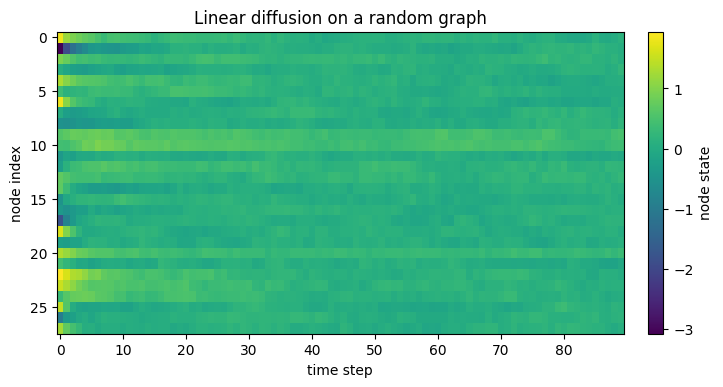

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8.0, 4.0), dpi=100)
im = ax.imshow(X_linear_demo.T, aspect="auto", interpolation="nearest")
ax.set_title("Linear diffusion on a random graph")
ax.set_xlabel("time step")
ax.set_ylabel("node index")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("node state")
plt.show()

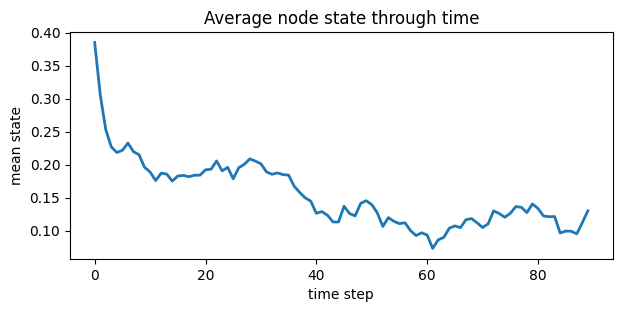

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(7.0, 3.0), dpi=100)
ax.plot(X_linear_demo.mean(axis=1), lw=2)
ax.set_title("Average node state through time")
ax.set_xlabel("time step")
ax.set_ylabel("mean state")
plt.show()

The heatmap above is our first important object of the day: a matrix of node states evolving in time. That is exactly the kind of observation many reconstruction problems start from.

The point is not that this averaging model is realistic in every domain. The point is that a graph plus a local update rule can leave visible traces in the data.


_______
### The Ising model on a random network

Now let the state be discrete. Each node carries a spin $s_i(t) \in \{-1,+1\}$.

We will use a simple ferromagnetic Ising model on a graph. Define the local field at node $i$ by

$$
h_i(t) = h + J \sum_j A_{ij} s_j(t),
$$

where:

- $h$ is a constant external field,
- $J > 0$ is the coupling strength on every edge,
- $A_{ij}$ tells us whether nodes $i$ and $j$ are connected, and
- $s_j(t)$ is the current spin of neighbor $j$.


Under a heat-bath ("Glauber"-style) update, the probability that node $i$ becomes $+1$ at the next update is

$$
\mathbb{P}(s_i(t+1)=+1 \mid s(t)) = \frac{1}{1 + \exp(-2 \beta h_i(t))}.
$$

Here $\beta \ge 0$ is the inverse temperature. Small $\beta$ means nearly random updates; large $\beta$ means much stronger alignment with the local field.

Why does this form make sense? If $h_i(t)$ is large and positive, then the exponential term is small and the probability of $+1$ becomes large. If $h_i(t)$ is negative, the probability moves toward $0$. If $h_i(t)=0$, the node is exactly indifferent and the probability is $1/2$.

In the code below:

- `state[i]` stores $s_i(t)$,
- `local_field` stores $h_i(t)$,
- `beta` stores $\beta$,
- `coupling` stores $J$, and
- `external_field` stores $h$.


In [9]:
def ising_prob_plus(local_field, beta):
    """Return the heat-bath probability that the next spin is +1."""
    local_field = np.asarray(local_field, dtype=float)
    return 1.0 / (1.0 + np.exp(-2.0 * beta * local_field))

neighbor_spins = np.array([1, 1, -1, 1])
coupling = 0.6
external_field = 0.0
beta = 0.8

local_field = external_field + coupling * neighbor_spins.sum()
p_plus = float(ising_prob_plus(local_field, beta))

print("neighbor spins         =", neighbor_spins)
print("local field h_i(t)     =", round(local_field, 3))
print("P(next spin = +1)      =", round(p_plus, 4))

neighbor spins         = [ 1  1 -1  1]
local field h_i(t)     = 1.2
P(next spin = +1)      = 0.8721


In [10]:
def simulate_ising_heatbath_demo(G, T=250, beta=0.45, coupling=0.55, external_field=0.0, rng_seed=0):
    """Simulate an Ising model on a graph using asynchronous heat-bath updates.

    One recorded time step corresponds to one sweep of n single-node updates.

    Parameters
    ----------
    G : networkx.Graph
        Undirected graph.
    T : int
        Number of recorded time steps.
    beta : float
        Inverse temperature.
    coupling : float
        Pairwise coupling J on every edge.
    external_field : float
        Constant external field h.
    rng_seed : int
        Random seed.

    Returns
    -------
    spins : ndarray, shape (T, n)
        Spin trajectories with entries in {-1, +1}.
    magnetization : ndarray, shape (T,)
        Mean spin at each recorded time step.
    """
    rng = make_rng(rng_seed)
    n = G.number_of_nodes()
    neighbors = [np.array(list(G.neighbors(i)), dtype=int) for i in range(n)]

    spins = np.zeros((T, n), dtype=int)
    state = rng.choice([-1, 1], size=n)
    spins[0] = state.copy()

    magnetization = np.zeros(T, dtype=float)
    magnetization[0] = state.mean()

    for t in range(1, T):
        for _ in range(n):
            i = int(rng.integers(0, n))
            nbrs = neighbors[i]
            local_field = external_field + coupling * state[nbrs].sum()
            p_plus = float(ising_prob_plus(local_field, beta))
            state[i] = 1 if rng.random() < p_plus else -1

        spins[t] = state.copy()
        magnetization[t] = state.mean()

    return spins, magnetization

In [11]:
G_ising_demo = largest_component_demo(nx.erdos_renyi_graph(40, 0.10, seed=21))
pos_ising_demo = nx.spring_layout(G_ising_demo, seed=21)

spins_ising_demo, magnetization_ising_demo = simulate_ising_heatbath_demo(
    G_ising_demo,
    T=250,
    beta=0.45,
    coupling=0.55,
    external_field=0.0,
    rng_seed=22,
)

In [12]:
final_spins = spins_ising_demo[-1]

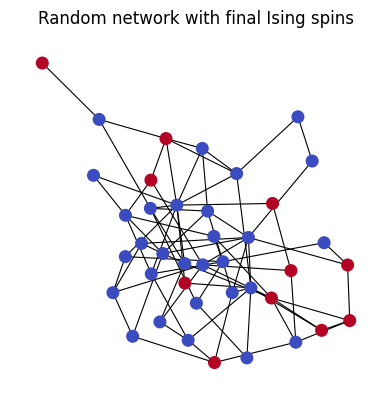

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(4.8, 4.8), dpi=100)
nx.draw_networkx(
    G_ising_demo,
    pos=pos_ising_demo,
    ax=ax,
    node_size=70,
    node_color=final_spins,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    with_labels=False,
    width=0.8,
)
ax.set_title("Random network with final Ising spins")
ax.set_axis_off()
plt.show()

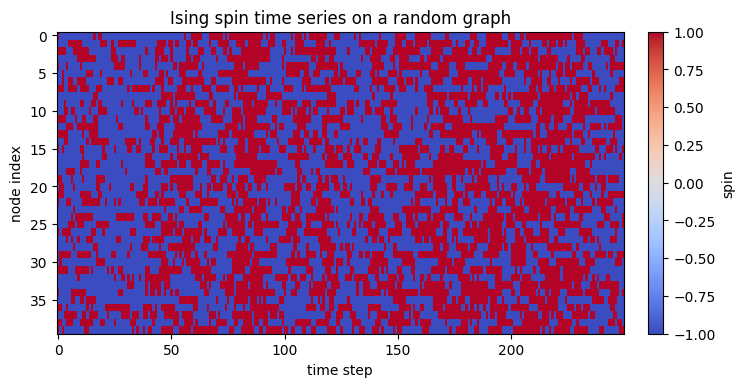

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8.0, 4.0), dpi=100)
im = ax.imshow(
    spins_ising_demo.T,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
ax.set_title("Ising spin time series on a random graph")
ax.set_xlabel("time step")
ax.set_ylabel("node index")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("spin")
plt.show()

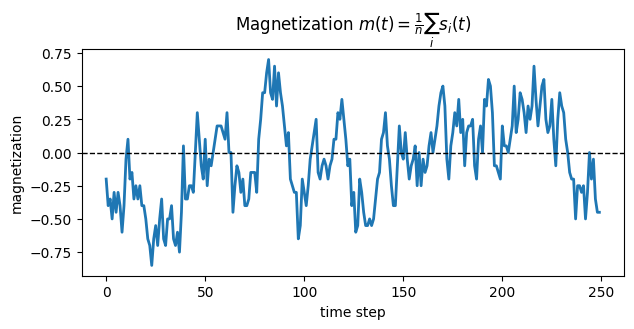

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(7.0, 3.0), dpi=100)
ax.plot(magnetization_ising_demo, lw=2)
ax.axhline(0.0, lw=1, linestyle="--", color='k')
ax.set_title("Magnetization $m(t) = \\frac{1}{n} \\sum_i s_i(t)$")
ax.set_xlabel("time step")
ax.set_ylabel("magnetization")
plt.show()

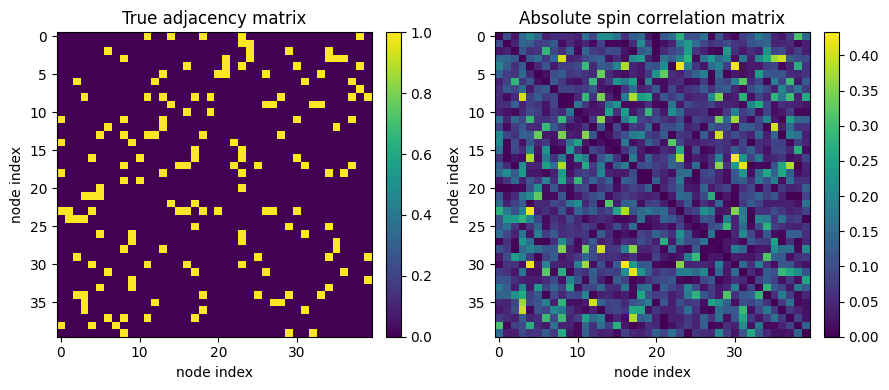

In [16]:
burn_in = 50
C_ising_demo = np.corrcoef(spins_ising_demo[burn_in:], rowvar=False)
C_ising_demo = np.nan_to_num(C_ising_demo, nan=0.0, posinf=0.0, neginf=0.0)
np.fill_diagonal(C_ising_demo, 0.0)

A_ising_demo = nx.to_numpy_array(G_ising_demo, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.0), dpi=100)

im0 = axes[0].imshow(A_ising_demo, aspect="auto", interpolation="nearest")
axes[0].set_title("True adjacency matrix")
axes[0].set_xlabel("node index")
axes[0].set_ylabel("node index")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(np.abs(C_ising_demo), aspect="auto", interpolation="nearest")
axes[1].set_title("Absolute spin correlation matrix")
axes[1].set_xlabel("node index")
axes[1].set_ylabel("node index")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [17]:
print("Correlation carries signal about the graph, but it is not the same object as the adjacency matrix.")


Correlation carries signal about the graph, but it is not the same object as the adjacency matrix.


The forward direction is now visible: graph $+$ dynamics $\to$ data.

Once we hide the graph and keep only the time series, the inverse question appears naturally: **can we work backward from the observations to the edges?** That is the game of network reconstruction.

The Ising example also highlights two practical points that will keep returning throughout the notebook. First, many different graphs can produce time series with similar high-level behavior, so identifiability is never automatic. Second, what many methods give us first is not a graph but a matrix of similarities, coefficients, or other edge scores. Turning those scores into a binary network requires thresholding or sparsification, which is exactly the theme from Class 02.


## Your turn!

What are possible dynamical processes that we can simulate over our graphs?

## 1. What does "network reconstruction" mean?

The warm-up above was the forward problem: we knew the graph, we simulated dynamics on it, and we looked at the resulting data. We now reverse that logic.

The term *network reconstruction* is used in several overlapping ways. In this notebook we focus on a specific (but broad) version:

> **We observe outcomes of a dynamical process and infer the edges that mediate interactions between nodes.**

That framing immediately raises questions you should always answer up front:


### What is the inference target?

- **Structural network**: the latent graph of actual interactions, or who can directly affect whom.
- **Functional network**: a summary of statistical dependence, or who co-varies with whom.
- **Effective or causal network**: directed influences under an assumed intervention or prediction model.

These can coincide in special cases, but they are not the same object. For example, correlation networks are *functional* summaries and can contain edges that are not present in the structural graph because of common-input confounding, indirect paths, or latent variables.


### What is observed?

Common observation types include:

- **Full node state time series** $X_{t,i}$, either continuous or discrete.
- **Partial observations**, where only some nodes or aggregate signals are measured.
- **Event times or cascades**, such as infection or adoption times across repeated runs.
- **Summary statistics**, such as covariances, correlations, or coherences.

### What assumptions tie edges to observations?

You cannot "read off" edges from observations without assumptions. Different literatures assume different forward models:

- linear dynamics, such as diffusion, consensus, Ornstein–Uhlenbeck, or VAR models;
- discrete-state dynamics, such as Ising-like updates, voter models, or SIS/SIR epidemics; and
- cascades or point processes, such as diffusion networks inferred from infection times.

A useful mental model is: reconstruction is inverse modeling. The network is hidden, and the observations are what the forward model produces.

A major theme of this notebook is that *identifiability* depends jointly on the graph family, the dynamics, the observation process, and the amount of data.

## 2. A forward-model viewpoint

The diffusion and Ising warm-ups above fit a common template. A very general way to write "dynamics on a graph" is

$$
x_i(t+1) = f\Big(x_i(t),\; \{x_j(t): A_{ij}=1\},\; \theta\Big) + \varepsilon_i(t),
$$

where:

- $x_i(t)$ is the state of node $i$ at time $t$,
- $f(\cdot)$ is an update rule, often nonlinear,
- $\theta$ collects model parameters such as infection rate, coupling strength, thresholds, or noise scale, and
- $\varepsilon_i(t)$ is process or measurement noise.

If we stack the node states into a vector $x(t)\in\mathbb{R}^n$, many models can also be written as

$$
x(t+1) = F\big(x(t); A, \theta\big) + \varepsilon(t).
$$

Reconstruction is the inverse problem: given observations of $x(t)$, infer $A$ and sometimes also infer parts of $\theta$.


### Two recurring ideas

1. **Sparsity or structure as a prior.**  
   In many domains the true interaction network is sparse, or has community or spatial structure. Enforcing that structure is often necessary for identifiability.

2. **Data must be informative.**  
   If the observed dynamics quickly collapses to a fixed point, such as everyone agreeing, everyone being infected, or everyone remaining inactive, then the time series contains little information about edges. Good reconstruction experiments make the informative regime explicit.


In [18]:
# A tiny numerical example of the generic forward-model template x(t+1) = F(x(t); A, theta) + epsilon(t)

A_small = np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0],
], dtype=float)

x_t = np.array([1.0, -0.5, 0.25])
alpha_small = 0.3
epsilon_t = np.array([0.02, -0.01, 0.00])

degrees_small = A_small.sum(axis=1)
W_small = np.divide(A_small, degrees_small[:, None], out=np.zeros_like(A_small), where=degrees_small[:, None] > 0)
x_next = (1 - alpha_small) * x_t + alpha_small * (W_small @ x_t) + epsilon_t

print("x(t)    =", np.round(x_t, 3))
print("A =")
print(A_small.astype(int))
print("x(t+1)  =", np.round(x_next, 3))

assert x_next.shape == x_t.shape


x(t)    = [ 1.   -0.5   0.25]
A =
[[0 1 0]
 [1 0 1]
 [0 1 0]]
x(t+1)  = [ 0.57  -0.172  0.025]


## 3. Identifiability and impossibility

"Identifiability" asks a simple question:

> If we had infinite data from the observation process, could we uniquely determine the network?

If the answer is "no," then no estimator can succeed without adding extra assumptions (priors, interventions, experimental design, etc.).



### 3.1 Underdetermination is the default

Many different networks can generate similar-looking observations. This is especially true if:

- observations are **low dimensional** (aggregate signals, heavy subsampling),
- the dynamics is near a **fixed point** most of the time,
- there are **unobserved nodes** that act as latent common causes,
- the forward model is misspecified (wrong update rule, wrong noise assumptions).

### 3.2 Functional dependence is not structure

Pairwise dependence measures (correlation, mutual information) are popular because they are easy to compute, but they can be misleading:

- **Indirect paths** create dependence even without a direct edge.  
- **Common inputs** can create strong dependence between nodes that are not connected.  
- **Degree effects**: high-degree nodes can become correlated with many nodes even when edges are not directly informative.

A good habit is to treat pairwise dependence as a *baseline*, not as definitive evidence of an edge.

### 3.3 A toy confounding example

In a moment we will simulate a simple three-node system where node 0 drives nodes 1 and 2. Nodes 1 and 2 become correlated even though there is no edge between them. This is the core reason "correlation → edge" is not generally valid.

### 3.4 What theory suggests

There are rigorous results showing that neighborhood selection with $\ell_1$ regularization can recover sparse graphs under conditions on sample size, incoherence conditions, and the strength of interactions (e.g., Gaussian graphical models and Ising models). These ideas underpin many reconstruction methods based on sparse regression and sparse inverse covariance estimation.


In [19]:
# Toy example: correlation can create a spurious edge through a common input

rng = make_rng(0)
T = 800

# Latent/common driver
x0 = rng.normal(size=T)

In [20]:
# Two observed variables both driven by x0, but with independent noise
b = 0.9
noise = 1.0
x1 = b * x0 + noise * rng.normal(size=T)
x2 = b * x0 + noise * rng.normal(size=T)

X = np.vstack([x0, x1, x2]).T  # shape (T, 3)

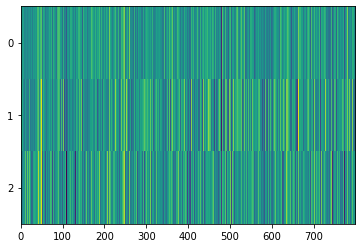

In [21]:
plt.imshow(X.T,aspect='auto',interpolation='none')
plt.yticks([2,1,0]);

In [22]:
corr = np.corrcoef(X.T)

df_corr = pd.DataFrame(corr, index=[0, 1, 2], columns=[0, 1, 2])
df_corr

,0,1,2
0,1.000000,0.700493,0.654932
1,0.700493,1.000000,0.473976
2,0.654932,0.473976,1.000000


In [23]:
print("corr(1,2) =", corr[1,2])
print("Even without a 1–2 edge, nodes 1 and 2 are correlated through node 0.")

corr(1,2) = 0.4739762388888955
Even without a 1–2 edge, nodes 1 and 2 are correlated through node 0.


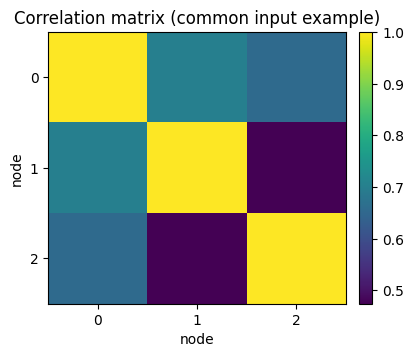

In [24]:
fig, ax = new_fig(figsize=(4.2, 3.6))
im = ax.imshow(corr, aspect='auto')
ax.set_title("Correlation matrix (common input example)")
ax.set_xticks([0,1,2])
ax.set_yticks([0,1,2])
ax.set_xlabel("node")
ax.set_ylabel("node")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

In the matrix above, $\mathrm{corr}(1,2)$ is typically nonzero because both nodes respond to the same driver $x_0(t)$. If you threshold correlations to build a graph, you will often add a **false edge** between nodes 1 and 2.

This does *not* mean correlation is useless. It means:

- correlation is a **baseline** (functional connectivity), not a structural guarantee, and  
- methods that condition on other variables (partial correlation, graphical lasso, sparse regression) are often better aligned with the goal of reconstructing edges.


## 4. Synthetic graph families for benchmarking

Benchmarking reconstruction methods on real data is hard because ground truth is rarely known. A standard strategy is to:

1. choose a family of graphs with controlled properties,
2. simulate dynamics on those graphs,
3. run reconstruction methods on the observations,
4. compare reconstructed edges to the known ground truth.

To learn robust lessons, we need multiple graph families that stress different structural features:

- **Erdős–Rényi (ER)**: relatively homogeneous degree; good "null" baseline.
- **Configuration-like graphs**: broad/heterogeneous degree sequences.
- **Stochastic block model (SBM)**: community structure and assortativity.
- **Spatial / random geometric graphs**: locality and short-range edges.

We will generate graphs with roughly comparable sizes and densities so that performance comparisons are meaningful.


In [25]:
def largest_connected_component(G):
    """Return the largest connected component of an undirected graph as a new graph."""
    if G.number_of_nodes() == 0:
        return G.copy()
    if nx.is_connected(G):
        return G.copy()
    comp = max(nx.connected_components(G), key=len)
    return G.subgraph(comp).copy()


def _simplify_multigraph(G):
    """Convert a (multi)graph to a simple undirected graph without self-loops."""
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from(G.edges())
    H.remove_edges_from(nx.selfloop_edges(H))
    return H


def _sample_powerlaw_degrees(n, k_avg, exponent, max_deg, rng):
    """Sample an integer degree sequence with a rough power-law shape."""
    deg = rng.zipf(exponent, size=n).astype(int)
    deg = np.clip(deg, 1, max_deg)

    # Rescale toward the target mean degree.
    scale = k_avg / deg.mean()
    deg = np.clip(np.round(deg * scale).astype(int), 1, max_deg)

    # Ensure an even sum of degrees.
    if deg.sum() % 2 == 1:
        deg[rng.integers(0, n)] += 1
        deg = np.clip(deg, 1, max_deg)

    return deg


def generate_graph(family, n, rng_seed, **params):
    """Generate a synthetic undirected graph and (optionally) node positions.

    Parameters
    ----------
    family : str
        One of: 'er', 'sbm', 'config', 'geo'.
    n : int
        Target number of nodes.
    rng_seed : int
        Random seed for reproducibility.
    params : dict
        Family-specific parameters.

    Returns
    -------
    G : networkx.Graph
        A simple undirected graph (largest connected component) with nodes labeled 0..n-1.
    pos : dict or None
        Positions for plotting when available (e.g., random geometric graphs).
    meta : dict
        Metadata describing how the graph was generated.
    """
    rng = make_rng(rng_seed)
    pos = None
    meta = dict(family=family, n=n, rng_seed=int(rng_seed), params=dict(params))

    if family == 'er':
        k_avg = params.get('k_avg', 6)
        p = k_avg / (n - 1)
        G = nx.erdos_renyi_graph(n, p, seed=int(rng_seed))

    elif family == 'sbm':
        sizes = params.get('sizes', [n // 2, n - n // 2])
        p_in = params.get('p_in', 0.20)
        p_out = params.get('p_out', 0.02)

        B = len(sizes)
        P = np.full((B, B), p_out)
        np.fill_diagonal(P, p_in)

        G = nx.stochastic_block_model(sizes, P, seed=int(rng_seed))
        meta['block_sizes'] = sizes
        meta['p_in'] = p_in
        meta['p_out'] = p_out

    elif family == 'config':
        k_avg = params.get('k_avg', 6)
        exponent = params.get('exponent', 2.5)
        max_deg = params.get('max_deg', max(10, int(0.2 * n)))

        deg = _sample_powerlaw_degrees(n, k_avg=k_avg, exponent=exponent, max_deg=max_deg, rng=rng)
        Gm = nx.configuration_model(deg, seed=int(rng_seed))
        G = _simplify_multigraph(Gm)
        meta['degree_sequence'] = deg

    elif family == 'geo':
        radius = params.get('radius', 0.25)
        G = nx.random_geometric_graph(n, radius, seed=int(rng_seed))
        pos = nx.get_node_attributes(G, 'pos')
        meta['radius'] = radius

    else:
        raise ValueError(f"Unknown family: {family}")

    # Keep only the largest connected component.
    G = largest_connected_component(G)

    # Relabel nodes to 0..n-1 for consistency, and preserve old labels so we can relabel pos.
    G = nx.convert_node_labels_to_integers(G, first_label=0, label_attribute='old_label')

    if pos is not None:
        new_pos = {}
        for new_node, data in G.nodes(data=True):
            old_node = data['old_label']
            new_pos[new_node] = pos[old_node]
        pos = new_pos

    # Remove the auxiliary attribute.
    for i in G.nodes():
        G.nodes[i].pop('old_label', None)

    return G, pos, meta


def describe_graph(G):
    """Return a small dictionary of summary stats."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    deg = np.array([d for _, d in G.degree()], dtype=float)
    return {
        "n": n,
        "m": m,
        "avg_degree": float(deg.mean()) if n > 0 else np.nan,
        "density": nx.density(G) if n > 1 else np.nan,
        "avg_clustering": nx.average_clustering(G) if n > 0 else np.nan,
        "connected": nx.is_connected(G) if n > 0 else False,
    }


In [26]:
# Generate one example from each graph family
n = 60
seed = 123

examples = [
    ("er", dict(k_avg=6)),
    ("config", dict(k_avg=6, exponent=2.5)),
    ("sbm", dict(sizes=[30, 30], p_in=0.20, p_out=0.02)),
    ("geo", dict(radius=0.25)),
]

graphs = {}
for fam, params in examples:
    G, pos, meta = generate_graph(fam, n=n, rng_seed=seed, **params)
    graphs[fam] = (G, pos, meta)

pd.DataFrame({fam: describe_graph(G) for fam, (G, _, _) in graphs.items()}).T


,n,m,avg_degree,density,avg_clustering,connected
er,60,192,6.4,0.108475,0.091793,True
config,60,153,5.1,0.086441,0.07966,True
sbm,60,207,6.9,0.116949,0.165661,True
geo,60,269,8.966667,0.151977,0.641507,True


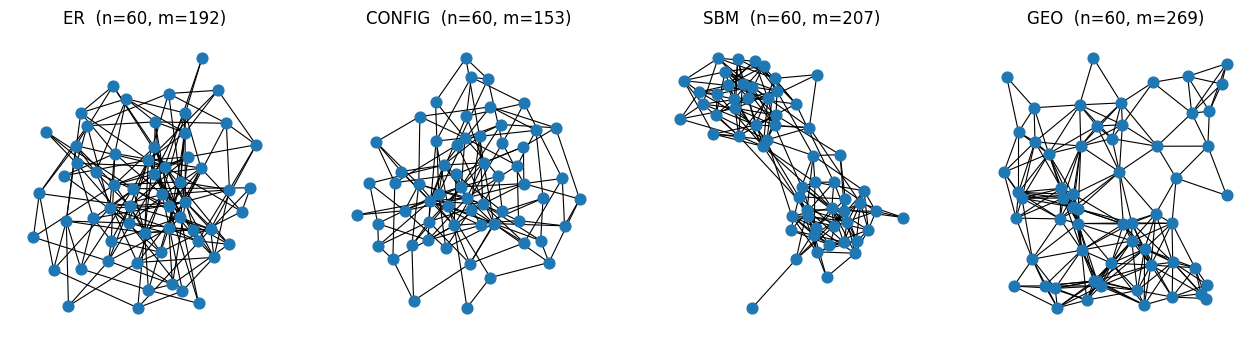

In [27]:
# Visualize the four benchmark graph families (one figure per family)
fig, ax = plt.subplots(1,4,figsize=(16.0, 4.0), dpi=100)
z = 0
for fam, (G, pos, meta) in graphs.items():
    if pos is None:
        pos = nx.spring_layout(G, seed=0)

    ax[z].set_title(f"{fam.upper()}  (n={G.number_of_nodes()}, m={G.number_of_edges()})")
    nx.draw_networkx(
        G, pos=pos, ax=ax[z],
        node_size=60,
        width=0.8,
        with_labels=False
    )
    ax[z].axis('off')
    z += 1

plt.show()

## 5. Reconstruction methods: from observations to edge scores

A reconstruction method takes observations, usually a multivariate time series, and returns **edge scores** $S_{ij}$.

You can think of $S_{ij}$ as answering the question: *how much evidence do we have that nodes $i$ and $j$ interact directly?*

![](images/netrd.png)

We will implement several widely used families:

1. **Pairwise dependence baselines**  
   - Pearson correlation  
   - Lag-1 cross-correlation  
   - Mutual information on discretized data

2. **Conditional dependence under a Gaussian approximation**  
   - Graphical lasso, which estimates a sparse inverse covariance

3. **Model-based neighborhood selection**  
   Fit a regularized model of each node's next state using all other nodes' current states. Nonzero coefficients are interpreted as candidate neighbors. This connects naturally to sparse regression ideas from earlier in the course and to classical results on neighborhood selection for Gaussian graphs and Ising models.

4. **Event-time scoring for cascades**  
   A simple precedence-based score using infection or adoption times. This is only a toy compared to full likelihood-based cascade models such as NetInf or NetRate, but it illustrates how the observation type matters.

This is intentionally a **small** menu. The broader literature also includes partial-correlation methods, sparse inverse-covariance models, transfer-entropy and Granger-causal approaches, deconvolution ideas, diffusion-network likelihood methods, compressive-sensing methods, Bayesian or MDL approaches, community-aware reconstruction, and time-varying models. In other words, there is no single "network reconstruction algorithm." There is a family of methods, and each family comes with assumptions.


### A useful external toolbox: `netrd`

If you want a broader landscape of reconstruction methods than we can fit into one class, [`netrd`](https://github.com/netsiphd/netrd) is a very useful reference point. It provides a common Python interface for many network-reconstruction methods, along with graph-distance tools for comparing the inferred networks.

In [28]:
import netrd

In [29]:
# dictionary of some example dynamics to play around with
dynamics = {'BranchingModel':              netrd.dynamics.BranchingModel(),
            'IsingGlauber':                netrd.dynamics.IsingGlauber(),
            'SherringtonKirkpatrickIsing': netrd.dynamics.SherringtonKirkpatrickIsing(),
            'VoterModel':                  netrd.dynamics.VoterModel()}

In [30]:
# select network for testing
G0 = nx.ring_of_cliques(4, 16)

# get average degree of the network
k_avg = np.mean(list(dict(G0.degree()).values()))

dyna_name = 'SherringtonKirkpatrickIsing'
# select the dynamical process you want to simulate on the network
D0 = dynamics[dyna_name]

# how long should the time series be?
L  = 2001

# simulate D0 dynamics on the network
TS = D0.simulate(G0, L)

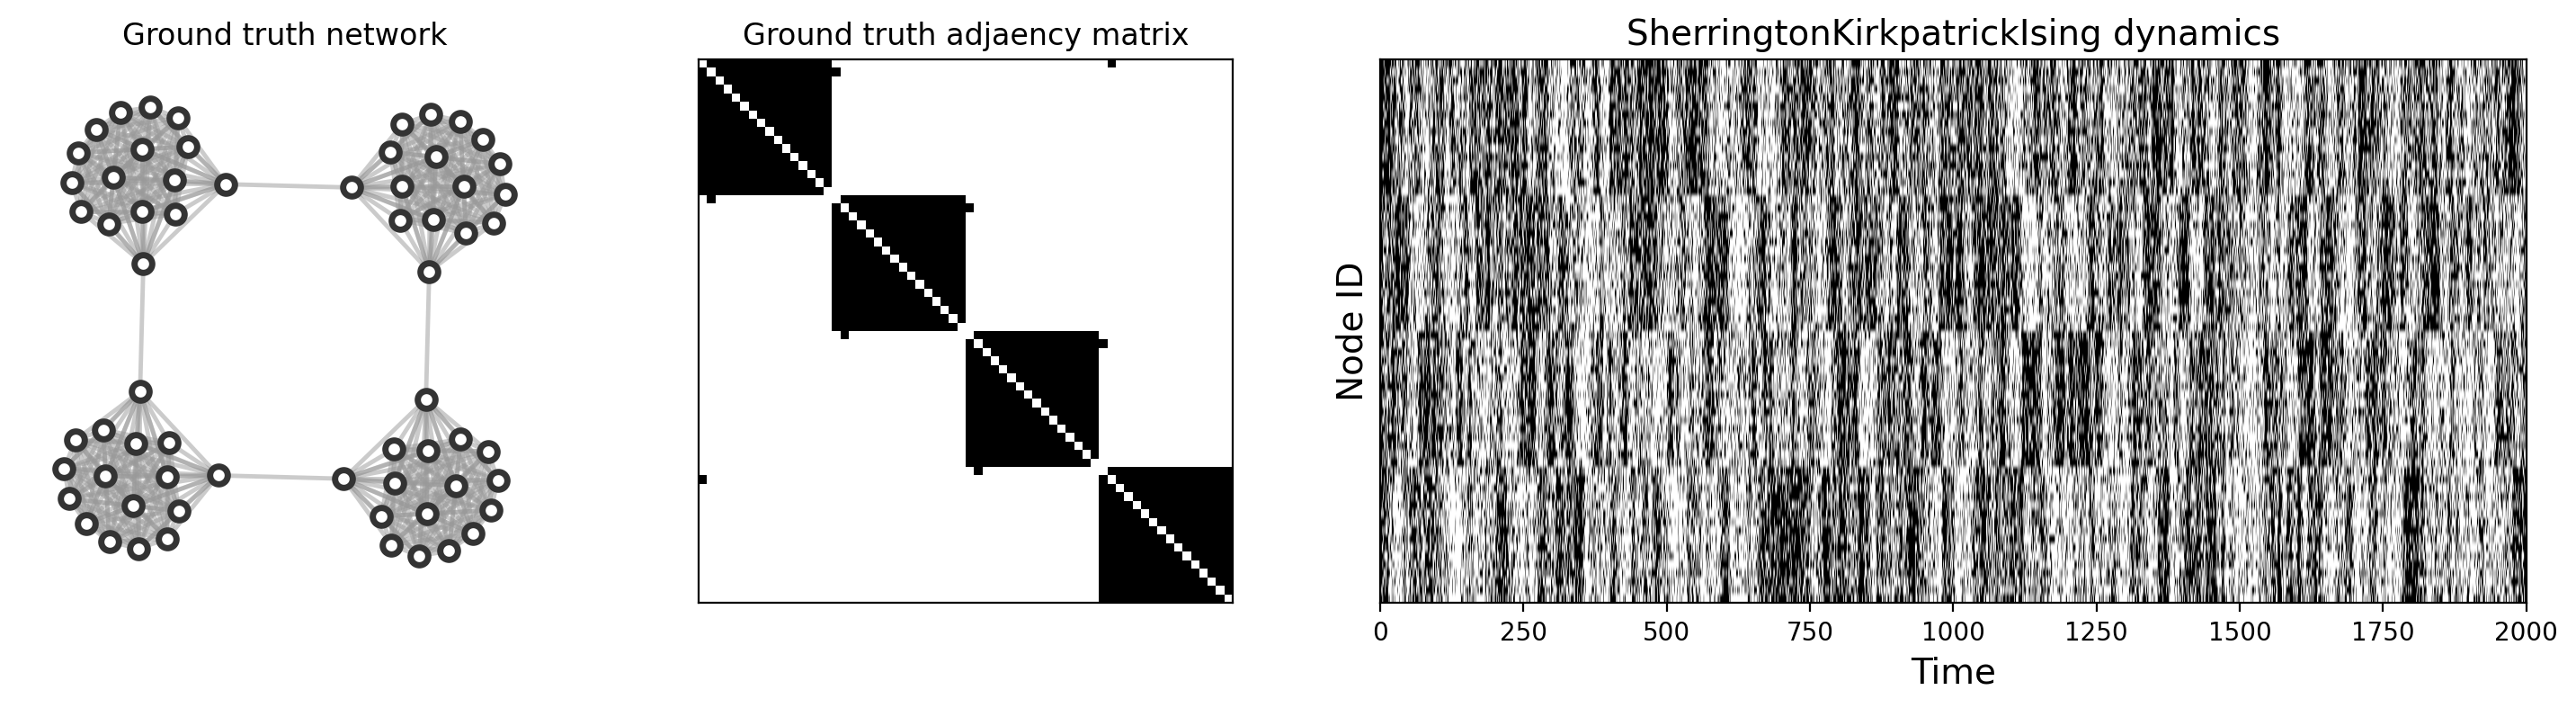

In [31]:
fig, ax = plt.subplots(1,3,figsize=(18,4),gridspec_kw={'width_ratios':[1,1,2.15]},dpi=200)

pos = nx.kamada_kawai_layout(G0)

nx.draw_networkx_nodes(G0, pos, node_size=50, node_color='w', linewidths=2.5, edgecolors='.2', ax=ax[0])
nx.draw_networkx_edges(G0, pos, width=1.75, edge_color='.6', alpha=0.5, ax=ax[0])
ax[0].set_title("Ground truth network")
ax[0].set_axis_off()

ax[1].imshow(nx.to_numpy_array(G0), cmap='Greys', aspect='auto')
ax[1].set_yticks([])
ax[1].set_xticks([])
ax[1].set_title("Ground truth adjaency matrix")

ax[2].imshow(TS, cmap='Greys', aspect='auto')
ax[2].set_yticks([])
ax[2].set_xlabel("Time", size=14)
ax[2].set_ylabel("Node ID", size=14)
ax[2].set_title("%s dynamics"%dyna_name, size=14)


plt.show()

In [32]:
# dictionary of some of the reconstruction techniques in netrd
# (leaving out some of the more computationally expensive ones)
recons = {
    'ConvergentCrossMapping':       netrd.reconstruction.ConvergentCrossMapping(),
    'CorrelationMatrix':            netrd.reconstruction.CorrelationMatrix(),
    'ExactMeanField':               netrd.reconstruction.MeanField(),
    'FreeEnergyMinimization':       netrd.reconstruction.FreeEnergyMinimization(),
    'GraphicalLasso':               netrd.reconstruction.GraphicalLasso(),
    'MarchenkoPastur':              netrd.reconstruction.MarchenkoPastur(),
    'MaximumLikelihoodEstimation':  netrd.reconstruction.MaximumLikelihoodEstimation(),
    'MutualInformationMatrix':      netrd.reconstruction.MutualInformationMatrix(),
    'OUInference':                  netrd.reconstruction.OUInference(),
    'ThoulessAndersonPalmer':       netrd.reconstruction.ThoulessAndersonPalmer()}

In [33]:
# for ease of visualization, we'll threshold all the reconstructions 
kwargs = {'threshold_type':'degree', 'avg_k':k_avg}

# dictionary to store the outputs
Wdict = {}

# loop over all the reconstruction techniques
for ri, R1 in list(recons.items()):
    R1.fit(TS, **kwargs)
    Wr = R1.results['thresholded_matrix']
    Wdict[ri] = Wr

In [34]:
import itertools as it

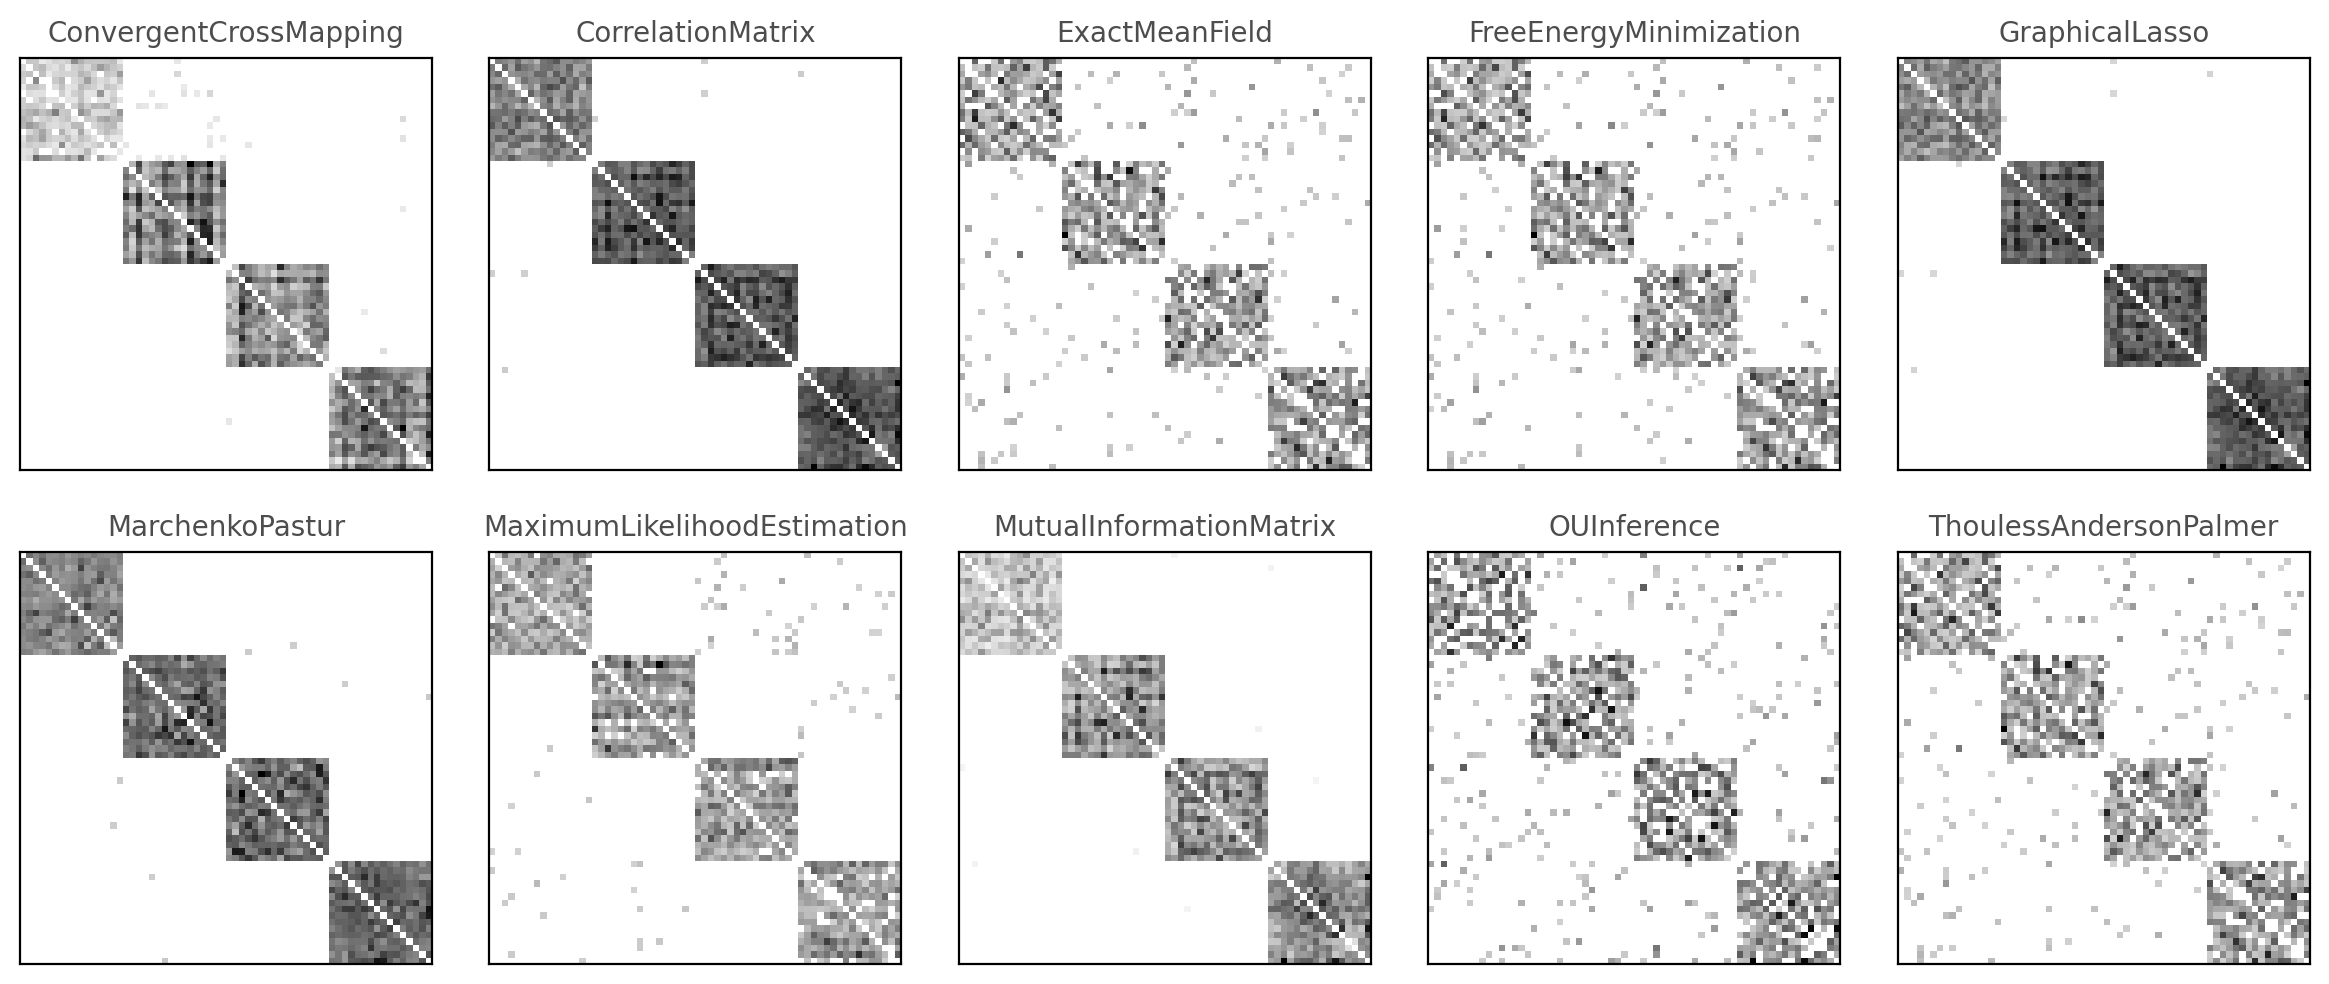

In [35]:
w = 3.0; h = 3.0
ncols = 5; nrows = 2
tups = list(it.product(range(nrows), range(ncols)))

fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*w,nrows*h), dpi=200)
plt.subplots_adjust(wspace=0.05,hspace=0.2)

ix = 0
for lab_i, W_i in Wdict.items():
    a = ax[tups[ix]]
    a.imshow(W_i, cmap='Greys')
    ix += 1
    a.set_title(lab_i, color='.3', fontsize='medium')
    a.set_yticks([])
    a.set_xticks([])

plt.show()

## Your turn!
Explore the `netrd` documentation and construct a series of tests about the role that network structure plays in success of reconstruction.

## 6. Forward models used in the benchmark

The warm-up above already showed a linear averaging process and an Ising model. For the main benchmarking harness below, we package several additional dynamical families into a common interface so we can compare reconstruction methods across different observation types and failure modes.

For each model we will:

1. write down a clear forward model,
2. implement a simulator from scratch,
3. specify what is observed, and
4. discuss a small identifiability point.

A crucial design choice is that we simulate **multiple independent runs or cascades** for each graph. Diverse initial conditions are often necessary for reconstruction. If every run starts from almost the same state and quickly converges, the data carries little information.

### A unified output format

Every simulator returns a dictionary with the same top-level structure:

- `obs['node_order']`: node labels in the order used by the data matrix,
- `obs['runs']`: a list of arrays, each of shape $(T, n)$,
- `obs['model']` and `obs['params']`: metadata describing the simulation.

Some models also provide event-time summaries, such as infection or adoption times, inside `obs['run_info']`.


In [36]:
def graph_adjacency_csr(G, nodelist=None, dtype=float):
    """Return the adjacency matrix as a SciPy CSR sparse matrix."""
    if nodelist is None:
        nodelist = list(range(G.number_of_nodes()))
    try:
        A = nx.to_scipy_sparse_array(G, nodelist=nodelist, format='csr', dtype=dtype)
    except AttributeError:
        # networkx < 3.0
        A = nx.to_scipy_sparse_matrix(G, nodelist=nodelist, format='csr', dtype=dtype)
    return A


def simulate_linear_diffusion(G, T=200, alpha=0.35, noise_std=0.15, x0_std=1.0, n_runs=5, rng_seed=0):
    """Linear diffusion / DeGroot-style consensus with additive noise.

    Update rule (row-stochastic coupling):
    x(t+1) = (1-alpha) x(t) + alpha W x(t) + noise

    where W = D^{-1}A is row-stochastic.

    Observations: full real-valued time series for all nodes.
    """
    n = G.number_of_nodes()
    A = graph_adjacency_csr(G, dtype=float)
    deg = np.asarray(A.sum(axis=1)).reshape(-1)
    deg[deg == 0] = 1.0
    Dinv = sparse.diags(1.0 / deg)
    W = Dinv @ A

    rng = make_rng(rng_seed)
    runs = []
    run_info = []

    for r in range(n_runs):
        x = np.zeros((T, n), dtype=float)
        x[0] = x0_std * rng.normal(size=n)
        for t in range(T - 1):
            x[t + 1] = (1 - alpha) * x[t] + alpha * (W @ x[t]) + noise_std * rng.normal(size=n)
        runs.append(x)
        run_info.append(dict(run_index=r))

    obs = {
        'model': 'linear_diffusion',
        'params': dict(T=T, alpha=alpha, noise_std=noise_std, x0_std=x0_std, n_runs=n_runs),
        'node_order': list(range(n)),
        'runs': runs,
        'run_info': run_info,
    }
    return obs


def simulate_sis(G, T=200, beta=0.25, mu=0.10, init_infected_frac=0.10, n_runs=20, rng_seed=0):
    """Discrete-time SIS epidemic on a fixed network.

    States: x_i(t) in {0,1} (0=susceptible, 1=infected).

    Synchronous update:
    - Susceptible node with m infected neighbors becomes infected with probability 1-(1-beta)^m.
    - Infected node recovers with probability mu.

    Observations: full binary state time series for all nodes.
    """
    n = G.number_of_nodes()
    A = graph_adjacency_csr(G, dtype=float)

    rng = make_rng(rng_seed)
    runs = []
    run_info = []

    for r in range(n_runs):
        x = np.zeros((T, n), dtype=int)
        x0 = rng.random(size=n) < init_infected_frac
        x[0] = x0.astype(int)

        for t in range(T - 1):
            infected = x[t].astype(float)
            infected_nbrs = np.asarray(A @ infected).reshape(-1)

            p_inf = 1.0 - np.power((1.0 - beta), infected_nbrs)
            new_infected = (rng.random(size=n) < p_inf) & (x[t] == 0)

            recovered = (rng.random(size=n) < mu) & (x[t] == 1)

            x[t + 1] = x[t]
            x[t + 1][new_infected] = 1
            x[t + 1][recovered] = 0

        runs.append(x.astype(float))  # store as float for method compatibility
        run_info.append(dict(run_index=r))

    obs = {
        'model': 'sis',
        'params': dict(T=T, beta=beta, mu=mu, init_infected_frac=init_infected_frac, n_runs=n_runs),
        'node_order': list(range(n)),
        'runs': runs,
        'run_info': run_info,
    }
    return obs


def simulate_voter(G, T=200, epsilon=0.02, init_p=0.5, n_runs=20, rng_seed=0):
    """Voter model with small independent noise.

    States: x_i(t) in {0,1}.

    One recorded time step corresponds to one sweep of n updates:
    - pick a random node i
    - with probability (1-epsilon), copy the state of a random neighbor
    - with probability epsilon, flip the state

    Observations: full binary state time series for all nodes.
    """
    n = G.number_of_nodes()
    neighbors = [np.array(list(G.neighbors(i)), dtype=int) for i in range(n)]

    rng = make_rng(rng_seed)
    runs = []
    run_info = []

    for r in range(n_runs):
        x = np.zeros((T, n), dtype=int)
        s = (rng.random(size=n) < init_p).astype(int)
        x[0] = s.copy()

        for t in range(T - 1):
            for _ in range(n):
                i = int(rng.integers(0, n))
                if len(neighbors[i]) == 0:
                    continue
                if rng.random() < epsilon:
                    s[i] = 1 - s[i]
                else:
                    j = int(neighbors[i][rng.integers(0, len(neighbors[i]))])
                    s[i] = s[j]
            x[t + 1] = s.copy()

        runs.append(x.astype(float))
        run_info.append(dict(run_index=r))

    obs = {
        'model': 'voter',
        'params': dict(T=T, epsilon=epsilon, init_p=init_p, n_runs=n_runs),
        'node_order': list(range(n)),
        'runs': runs,
        'run_info': run_info,
    }
    return obs


def simulate_threshold_cascades(G, T=40, phi_low=0.15, phi_high=0.35, seed_size=3, n_cascades=40, rng_seed=0):
    """Threshold (complex contagion) cascades à la Watts.

    States: x_i(t) in {0,1}, and once a node adopts it stays adopted.

    Each node i has a threshold phi_i in [phi_low, phi_high]. In each cascade:
    - choose a small random seed set at t=0
    - at each t>0, an inactive node adopts if (active neighbors / degree) >= phi_i

    Observations:
    - binary state time series per cascade
    - adoption time per node per cascade (inf if never adopts)
    """
    n = G.number_of_nodes()
    A = graph_adjacency_csr(G, dtype=float)
    deg = np.asarray(A.sum(axis=1)).reshape(-1)
    deg[deg == 0] = 1.0

    rng = make_rng(rng_seed)
    phi = rng.uniform(phi_low, phi_high, size=n)

    runs = []
    run_info = []

    for c in range(n_cascades):
        active = np.zeros(n, dtype=int)
        seeds = rng.choice(n, size=min(seed_size, n), replace=False)
        active[seeds] = 1

        inf_time = np.full(n, np.inf)
        inf_time[seeds] = 0.0

        X = np.zeros((T, n), dtype=int)
        X[0] = active.copy()

        for t in range(T - 1):
            frac_active = np.asarray(A @ active).reshape(-1) / deg
            new_active = (active == 0) & (frac_active >= phi)
            if not np.any(new_active):
                X[t + 1] = active.copy()
                continue

            active[new_active] = 1
            inf_time[new_active] = float(t + 1)
            X[t + 1] = active.copy()

        runs.append(X.astype(float))
        run_info.append(dict(cascade_index=c, thresholds=phi.copy(), infection_times=inf_time))

    obs = {
        'model': 'threshold',
        'params': dict(T=T, phi_low=phi_low, phi_high=phi_high, seed_size=seed_size, n_cascades=n_cascades),
        'node_order': list(range(n)),
        'runs': runs,
        'run_info': run_info,
        'thresholds': phi.copy(),
    }
    return obs


def simulate_dynamics(G, model_name, params, rng_seed=0):
    """Unified interface: simulate dynamics and return observations."""
    model_name = str(model_name).lower()

    if model_name in ['linear', 'linear_diffusion', 'diffusion', 'degroot']:
        return simulate_linear_diffusion(G, rng_seed=rng_seed, **params)
    if model_name in ['sis', 'epidemic']:
        return simulate_sis(G, rng_seed=rng_seed, **params)
    if model_name in ['voter', 'opinion']:
        return simulate_voter(G, rng_seed=rng_seed, **params)
    if model_name in ['threshold', 'cascade']:
        return simulate_threshold_cascades(G, rng_seed=rng_seed, **params)

    raise ValueError(f"Unknown model_name: {model_name}")

print("Dynamics simulators ready.")


Dynamics simulators ready.


### 6.1 Linear diffusion / consensus (DeGroot-style)

A convenient starting point is **linear dynamics** because we can write it in matrix form and connect reconstruction to regression.

Let $x(t) \in \mathbb{R}^n$ be node states. Define the row-stochastic matrix $W = D^{-1}A$, where $D$ is the diagonal degree matrix. Consider

$$
x(t+1) = (1-\alpha) x(t) + \alpha W x(t) + \sigma\,\eta(t),
$$

where:

- $\alpha \in [0,1]$ is a coupling strength,
- $\sigma > 0$ sets the noise or excitation scale, and
- $\eta(t) \sim \mathcal{N}(0, I)$ are independent Gaussian shocks.

This form makes sense for the same reason as in the warm-up: nodes keep part of their current state, move partway toward a neighborhood average, and receive fresh noise. In the simulator below, $W$ is stored as `W`, $\alpha$ as `alpha`, $\sigma$ as `noise_std`, and the Gaussian shocks are generated by `rng.normal(size=n)`.

**What is observed?** In our synthetic benchmark, we observe the full real-valued time series $x_i(t)$ for every node.

**Toy identifiability point.** If $\sigma$ is tiny and $\alpha$ is large, trajectories quickly approach consensus and edge information is washed out. If $\alpha$ is tiny, nodes barely interact and edge information is also weak. Reconstruction is best in an intermediate regime with persistent variation.


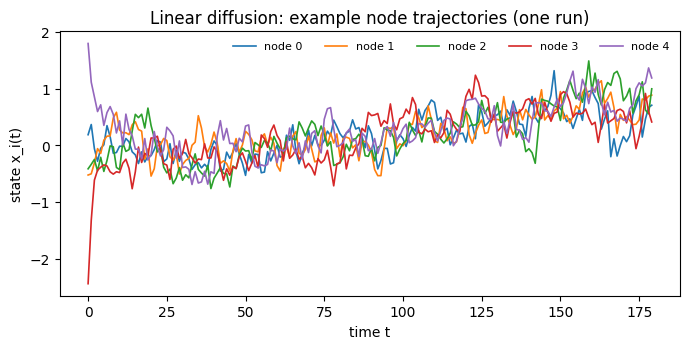

In [37]:
# Example: linear diffusion on an SBM graph
G_lin, pos_lin, _ = generate_graph('sbm', n=50, rng_seed=1, sizes=[25,25], p_in=0.25, p_out=0.03)

obs_lin = simulate_dynamics(
    G_lin,
    model_name='linear_diffusion',
    params=dict(T=180, alpha=0.35, noise_std=0.20, x0_std=1.0, n_runs=3),
    rng_seed=2,
)

# Plot a few node trajectories from the first run
X0 = obs_lin['runs'][0]
nodes_to_plot = [0, 1, 2, 3, 4]

fig, ax = new_fig(figsize=(8, 3.5))
for i in nodes_to_plot:
    ax.plot(X0[:, i], lw=1.2, label=f"node {i}")
ax.set_title("Linear diffusion: example node trajectories (one run)")
ax.set_xlabel("time t")
ax.set_ylabel("state x_i(t)")
ax.legend(ncol=5, fontsize=8, frameon=False, loc='upper right')
plt.show()


### 6.2 Epidemic spreading: SIS

In SIS (susceptible $\to$ infected $\to$ susceptible), each node is in state $x_i(t)\in\{0,1\}$.

A common discrete-time model is:

- If $x_i(t)=0$ and $m_i(t)$ neighbors are infected, then

$$
\mathbb{P}(x_i(t+1)=1 \mid x(t)) = 1 - (1-\beta)^{m_i(t)},
$$

where $\beta$ is the per-neighbor infection probability per time step.

- If $x_i(t)=1$, then

$$
\mathbb{P}(x_i(t+1)=0 \mid x(t)) = \mu,
$$

where $\mu$ is the recovery probability per time step.

Why does this form make sense? If a susceptible node has no infected neighbors, then $m_i(t)=0$ and the infection probability is $0$. As $m_i(t)$ increases, the infection probability rises toward $1$. In the simulator below, `infected_nbrs[i]` stores $m_i(t)$, `beta` stores $\beta$, and `mu` stores $\mu$.

**What is observed?** In our synthetic benchmark, we observe the full binary infection time series for every node across multiple runs with randomized initial infections.

**Toy identifiability point.** If the epidemic almost always dies out quickly or saturates, the time series has little variation and reconstruction becomes difficult.


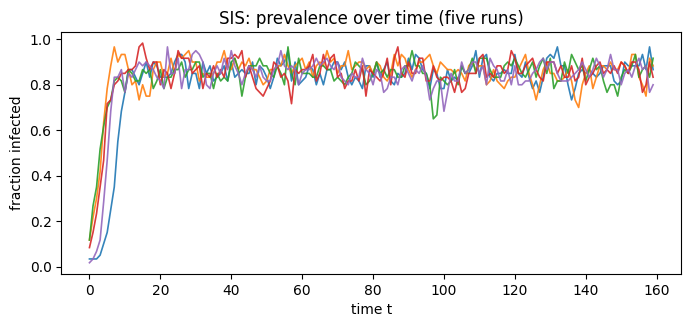

In [38]:
# Small numerical example for the SIS infection rule
beta_demo = 0.22
infected_neighbor_counts = np.arange(5)
infection_probs = 1.0 - (1.0 - beta_demo) ** infected_neighbor_counts

display_df = pd.DataFrame({
    "infected_neighbors": infected_neighbor_counts,
    "P(infection next step)": np.round(infection_probs, 3),
})
display_df

# Example: SIS on a degree-heterogeneous (configuration-like) graph
G_sis, pos_sis, _ = generate_graph('config', n=60, rng_seed=3, k_avg=6, exponent=2.5)

obs_sis = simulate_dynamics(
    G_sis,
    model_name='sis',
    params=dict(T=160, beta=0.22, mu=0.10, init_infected_frac=0.10, n_runs=10),
    rng_seed=4,
)

# Plot prevalence (fraction infected) over time for a few runs
fig, ax = new_fig(figsize=(8, 3.2))
for r in range(5):
    Xr = obs_sis['runs'][r]
    prevalence = Xr.mean(axis=1)
    ax.plot(prevalence, lw=1.2, alpha=0.9)
ax.set_title("SIS: prevalence over time (five runs)")
ax.set_xlabel("time t")
ax.set_ylabel("fraction infected")
plt.show()


### 6.3 Discrete opinion dynamics: voter model (with noise)

In the voter model, nodes hold a discrete "opinion" state $x_i(t)\in\{0,1\}$. Informally, nodes repeatedly copy a neighbor’s opinion.

We implement an asynchronous update in sweeps:

1. pick a random node $i$  
2. with probability $1-\epsilon$, set $x_i \leftarrow x_j$ where $j$ is a random neighbor  
3. with probability $\epsilon$, flip $x_i$ (independent noise)

**What is observed?** In our synthetic benchmark: full binary time series for all nodes, across multiple runs.

**Toy identifiability point.** Many voter-model trajectories drift toward consensus. Once almost all nodes share the same state, edge information becomes weak. Adding a small noise rate $\epsilon$ helps keep the dynamics informative.


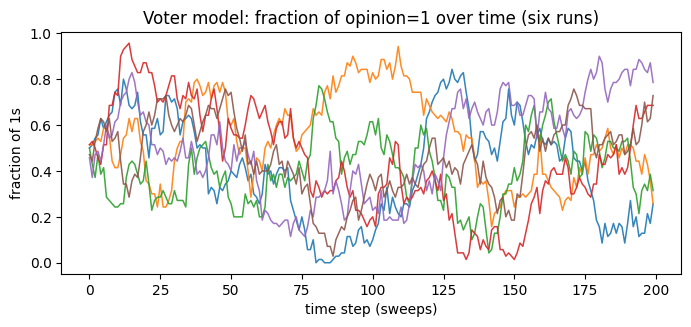

In [39]:
# Example: voter model on a spatial graph
G_voter, pos_voter, _ = generate_graph('geo', n=70, rng_seed=5, radius=0.22)

obs_voter = simulate_dynamics(
    G_voter,
    model_name='voter',
    params=dict(T=200, epsilon=0.02, init_p=0.5, n_runs=8),
    rng_seed=6,
)

fig, ax = new_fig(figsize=(8, 3.2))
for r in range(6):
    Xr = obs_voter['runs'][r]
    mag = Xr.mean(axis=1)  # in {0,1}, this is the fraction of 1's
    ax.plot(mag, lw=1.1, alpha=0.9)
ax.set_title("Voter model: fraction of opinion=1 over time (six runs)")
ax.set_xlabel("time step (sweeps)")
ax.set_ylabel("fraction of 1s")
plt.show()


### 6.4 Threshold cascades (complex contagion)

Threshold models represent **social reinforcement**: adopting a behavior may require multiple exposures.

Each node has a threshold $\phi_i \in (0,1)$. Let $x_i(t)\in\{0,1\}$ denote whether node $i$ has adopted by time $t$, with adoption absorbing once it happens. Define the fraction of active neighbors

$$
f_i(t) = \frac{1}{d_i} \sum_j A_{ij} x_j(t),
$$

where $d_i$ is the degree of node $i$. The update is

$$
x_i(t+1) =
\begin{cases}
1 & \text{if } x_i(t)=1 \text{ or } f_i(t) \ge \phi_i, \\
0 & \text{otherwise.}
\end{cases}
$$

Why does this form make sense? A node adopts only when the active fraction in its neighborhood crosses a personal threshold. In the simulator below, `phi[i]` stores $\phi_i$, `deg[i]` stores $d_i$, and `frac_active[i]` stores $f_i(t)$.

**What is observed?** In our synthetic benchmark we observe the binary adoption time series for each cascade and also the adoption time $\tau_i$, the first time at which node $i$ adopts.

**Toy identifiability point.** A single cascade rarely identifies edges uniquely. Many graphs can support the same adoption order. Multiple cascades with varied seed sets provide more constraints.


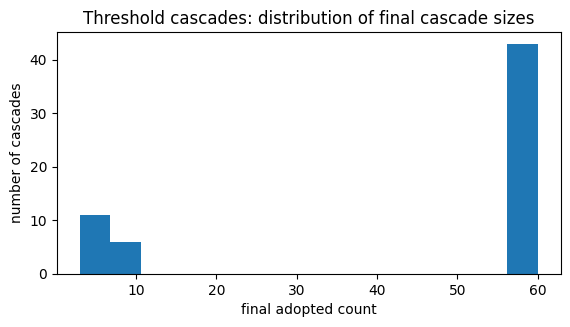

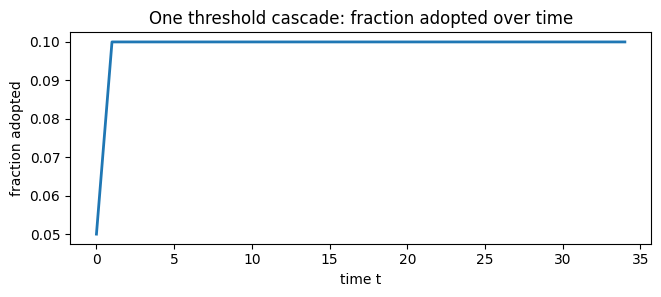

In [40]:
# Small numerical example for the threshold rule
frac_active_demo = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
phi_demo = 0.40
toy_threshold_df = pd.DataFrame({
    "active_neighbor_fraction": frac_active_demo,
    "adopt_if_phi=0.40": (frac_active_demo >= phi_demo).astype(int),
})
toy_threshold_df

# Example: threshold cascades on an ER graph
G_thr, pos_thr, _ = generate_graph('er', n=60, rng_seed=7, k_avg=6)

obs_thr = simulate_dynamics(
    G_thr,
    model_name='threshold',
    params=dict(T=35, phi_low=0.15, phi_high=0.35, seed_size=3, n_cascades=60),
    rng_seed=8,
)

# Cascade size = final number of adopted nodes
final_sizes = np.array([run[-1].sum() for run in obs_thr['runs']])

fig, ax = new_fig(figsize=(6.5, 3.2))
ax.hist(final_sizes, bins=15)
ax.set_title("Threshold cascades: distribution of final cascade sizes")
ax.set_xlabel("final adopted count")
ax.set_ylabel("number of cascades")
plt.show()

# Visualize adoption over time for one cascade
Xc = obs_thr['runs'][0]
fig, ax = new_fig(figsize=(7.5, 2.8))
ax.plot(Xc.mean(axis=1), lw=2)
ax.set_title("One threshold cascade: fraction adopted over time")
ax.set_xlabel("time t")
ax.set_ylabel("fraction adopted")
plt.show()


## 7. What the reconstruction algorithm gets to see

So far our simulators output "clean" node states. In practice, observations can be limited in several ways:

- **Measurement noise**: continuous states observed with additive noise; binary states observed with flips.
- **Partial node observation**: only a subset of nodes is recorded.
- **Limited sampling**: short time series, few cascades, coarse time resolution.

Our benchmark harness will include knobs for:

- number of runs/cascades,
- time horizon $T$,
- measurement noise,
- observed-node fraction.

To make these manipulations consistent, we implement observation post-processing functions that operate on the unified `obs` format.


In [41]:
def is_binary_model(model_name):
    """Return True if the model produces binary node states.

    In this notebook we treat SIS, voter, and threshold-cascade dynamics as binary
    (0/1) processes. Most other forward models here are real-valued.
    """
    return str(model_name).lower() in ['sis', 'voter', 'threshold']


def subsample_nodes(obs, observed_frac=1.0, rng_seed=0):
    """Keep only a random subset of nodes (an induced subproblem).

    This is a simple way to study partial observability. We randomly keep a subset
    of nodes and restrict all recorded node-state trajectories to those nodes.

    Parameters
    ----------
    obs : dict
        Observation dictionary returned by `simulate_dynamics`.
    observed_frac : float
        Fraction of nodes to keep (between 0 and 1). If >= 1.0, this is a no-op.
    rng_seed : int
        Seed for the node subsampling RNG.

    Returns
    -------
    new_obs : dict
        A new observation dict with:
        - 'node_order' restricted to the kept node labels,
        - each run restricted to the kept nodes,
        - event-time arrays (if present) restricted consistently.

    Notes
    -----
    Evaluation after subsampling is subtle. If you truly cannot observe the omitted
    nodes, then their influence becomes a latent confounder; in general, the induced
    subgraph on the observed nodes is *not* the same as the effective dependency
    structure among the observed variables. In this notebook, we deliberately keep
    evaluation simple by scoring against the induced ground-truth subgraph.
    """
    if observed_frac >= 1.0:
        return obs

    rng = make_rng(rng_seed)
    node_order = list(obs['node_order'])
    n = len(node_order)

    k = max(2, int(np.floor(observed_frac * n)))
    keep_idx = np.sort(rng.choice(n, size=k, replace=False))

    keep_labels = [node_order[i] for i in keep_idx]
    new_runs = [run[:, keep_idx] for run in obs['runs']]

    new_obs = dict(obs)
    new_obs['node_order'] = keep_labels
    new_obs['runs'] = new_runs
    new_obs['params'] = dict(obs.get('params', {}))
    new_obs['params']['observed_frac'] = observed_frac
    new_obs['params']['observed_nodes'] = keep_labels

    # Restrict per-run metadata (event times, thresholds) when present.
    new_run_info = []
    for info in obs.get('run_info', []):
        info2 = dict(info)
        if 'infection_times' in info2 and info2['infection_times'] is not None:
            info2['infection_times'] = np.asarray(info2['infection_times'])[keep_idx]
        if 'thresholds' in info2 and info2['thresholds'] is not None:
            info2['thresholds'] = np.asarray(info2['thresholds'])[keep_idx]
        new_run_info.append(info2)
    new_obs['run_info'] = new_run_info

    # Some models store global thresholds as well.
    if 'thresholds' in new_obs:
        new_obs['thresholds'] = np.asarray(new_obs['thresholds'])[keep_idx]

    return new_obs


def add_measurement_noise(obs, noise_level=0.0, rng_seed=0):
    """Add a simple measurement-noise model to the observed node states.

    Parameters
    ----------
    obs : dict
        Observation dictionary returned by `simulate_dynamics`.
    noise_level : float
        - Continuous models: additive Gaussian noise with std = noise_level.
        - Binary models: independent bit-flip probability = noise_level.
        If <= 0, this is a no-op.
    rng_seed : int
        Seed for the noise RNG.

    Returns
    -------
    new_obs : dict
        A new observation dict with noised trajectories.

    Notes
    -----
    This is intentionally a *measurement* noise model, not a model of process noise.
    It is appropriate when you want to stress-test robustness to imperfect sensors.
    """
    if noise_level <= 0:
        return obs

    rng = make_rng(rng_seed)
    model = obs['model']
    new_obs = dict(obs)
    new_runs = []

    if is_binary_model(model):
        p = float(noise_level)
        for run in obs['runs']:
            X = run.copy()
            flips = rng.random(size=X.shape) < p
            X[flips] = 1.0 - X[flips]
            new_runs.append(X)
    else:
        sigma = float(noise_level)
        for run in obs['runs']:
            X = run.copy()
            X = X + sigma * rng.normal(size=X.shape)
            new_runs.append(X)

    new_obs['runs'] = new_runs
    new_obs['params'] = dict(obs.get('params', {}))
    new_obs['params']['measurement_noise'] = noise_level

    return new_obs


def stack_transitions(obs):
    """Build stacked one-step pairs $(x(t), x(t+1)) from all runs.

    Returns
    -------
    X_prev : array, shape (N_samples, n)
        States at time t.
    X_next : array, shape (N_samples, n)
        States at time t+1.
    """
    X_prev_list = []
    X_next_list = []
    for run in obs['runs']:
        X_prev_list.append(run[:-1])
        X_next_list.append(run[1:])
    X_prev = np.vstack(X_prev_list)
    X_next = np.vstack(X_next_list)
    return X_prev, X_next


def get_event_times(obs):
    """Extract per-run event-time arrays (infection/adoption times), if present.

    Returns
    -------
    times : list of arrays or None
        If present, returns a list containing one array of length n per run.
        If event times are not available for this observation type, returns None.
    """
    times = []
    for info in obs.get('run_info', []):
        if 'infection_times' in info:
            times.append(np.asarray(info['infection_times']))
    if len(times) == 0:
        return None
    return times

### Scores are not yet a graph

Most reconstruction procedures do **not** directly output a binary adjacency matrix. They output a score matrix $S$, and then we still need a decision rule to convert scores into edges:

- choose a hard threshold $\tau$,
- keep a fixed edge density,
- keep the top-$k$ pairs, or
- apply a significance or false-discovery rule.

This is exactly where today's topic reconnects to **Class 02**. Thresholding and sparsification are not neutral post-processing steps. They change degree distributions, clustering, connectedness, and all downstream network statistics. For that reason, we will usually treat edge ranking as the default task and postpone hard thresholding as long as possible.


In [42]:
def scores_correlation(obs, use_abs=True):
    """Pearson correlation baseline: score_{ij} = corr(x_i, x_j)."""
    X_all = np.vstack(obs['runs'])  # shape (N_samples, n)
    C = np.corrcoef(X_all, rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(C, 0.0)
    if use_abs:
        C = np.abs(C)
    return C


def scores_lagged_correlation(obs, use_abs=True):
    """Lag-1 cross-correlation baseline.

    score_{j->i} = corr(x_j(t), x_i(t+1)), computed from stacked transitions.
    Returned matrix is symmetric (max over directions).
    """
    X_prev, X_next = stack_transitions(obs)  # shapes (N_samples, n)

    Xp = X_prev - X_prev.mean(axis=0, keepdims=True)
    Xn = X_next - X_next.mean(axis=0, keepdims=True)

    Xp_std = Xp.std(axis=0, ddof=1, keepdims=True)
    Xn_std = Xn.std(axis=0, ddof=1, keepdims=True)
    Xp_std[Xp_std == 0] = 1.0
    Xn_std[Xn_std == 0] = 1.0

    Xp = Xp / Xp_std
    Xn = Xn / Xn_std

    S_dir = (Xp.T @ Xn) / (Xp.shape[0] - 1)
    S_dir = np.nan_to_num(S_dir, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(S_dir, 0.0)

    if use_abs:
        S_dir = np.abs(S_dir)

    S = np.maximum(S_dir, S_dir.T)
    return S


def scores_mutual_information(obs, nbins=6):
    """Mutual information baseline on discretized data."""
    X_all = np.vstack(obs['runs'])
    n = X_all.shape[1]

    if is_binary_model(obs['model']):
        Xd = X_all.astype(int)
    else:
        Xd = np.zeros_like(X_all, dtype=int)
        for j in range(n):
            col = X_all[:, j]
            edges = np.quantile(col, np.linspace(0, 1, nbins + 1))
            edges = np.unique(edges)
            if len(edges) <= 2:
                Xd[:, j] = 0
            else:
                Xd[:, j] = np.digitize(col, edges[1:-1], right=False)

    from sklearn.metrics import mutual_info_score

    MI = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            mi = mutual_info_score(Xd[:, i], Xd[:, j])
            MI[i, j] = mi
            MI[j, i] = mi

    np.fill_diagonal(MI, 0.0)
    return MI


def scores_graphical_lasso(obs, alpha=0.02, max_iter=2000, tol=1e-4):
    r"""Graphical lasso edge scores via a sparse inverse covariance estimate.

    We fit a Gaussian graphical model by solving a penalized maximum-likelihood problem
    for the precision matrix Θ (the inverse covariance). Under Gaussian assumptions,
    nonzero off-diagonal entries of Θ correspond to conditional dependencies.

    In practice, it is often more interpretable to convert Θ into **partial correlations**:

    $$

    \rho_{ij\mid \text{others}} = -\frac{\Theta_{ij}}{\sqrt{\Theta_{ii}\,\Theta_{jj}}}.

    $$

    This function returns $|\rho_{ij\mid \text{others}}|$ as the edge-score matrix.

    Parameters
    ----------
    obs : dict
        Observation dictionary with continuous-valued runs.
    alpha : float
        L1 regularization strength for graphical lasso.
    max_iter : int
        Maximum iterations for the solver.
    tol : float
        Convergence tolerance.

    Returns
    -------
    S : ndarray, shape (n, n)
        Symmetric score matrix (larger => stronger conditional association).

    Notes
    -----
    - Graphical lasso is most defensible when samples are approximately i.i.d. Gaussian.
      For strongly dynamical data, it is a baseline rather than a guaranteed-consistent estimator.
    - Standardizing variables (unit variance) makes the result closer to a sparse *inverse correlation*.
    """
    import warnings

    X_all = np.vstack(obs['runs'])

    # Work in standardized coordinates so the penalty is less scale-dependent.
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xz = scaler.fit_transform(X_all)

    model = GraphicalLasso(alpha=float(alpha), max_iter=int(max_iter), tol=float(tol))
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        model.fit(Xz)

    Theta = model.precision_.copy()

    # Convert precision to partial correlation
    d = np.sqrt(np.clip(np.diag(Theta), 1e-12, np.inf))
    P = -Theta / np.outer(d, d)

    S = np.abs(P)
    np.fill_diagonal(S, 0.0)
    S = np.nan_to_num(S, nan=0.0, posinf=0.0, neginf=0.0)
    return S


def _split_transitions_by_run(obs, train_frac=0.7):
    """Time-aware split: split transitions within each run into train/val."""
    Xp_tr, Xn_tr, Xp_va, Xn_va = [], [], [], []
    for run in obs['runs']:
        T = run.shape[0]
        n_trans = T - 1
        cut = max(1, int(np.floor(train_frac * n_trans)))
        Xp = run[:-1]
        Xn = run[1:]
        Xp_tr.append(Xp[:cut])
        Xn_tr.append(Xn[:cut])
        Xp_va.append(Xp[cut:])
        Xn_va.append(Xn[cut:])
    return np.vstack(Xp_tr), np.vstack(Xn_tr), np.vstack(Xp_va), np.vstack(Xn_va)


def scores_neighborhood_l1(obs, train_frac=0.7, alphas=None, Cs=None, max_iter=3000):
    """Sparse neighborhood selection via L1-regularized regression.

    - Continuous models: Lasso regression on one-step transitions.
    - Binary models: logistic regression with L1 penalty on one-step transitions.

    Returns
    -------
    S : ndarray, shape (n, n)
        Symmetric score matrix based on absolute fitted coefficients.
    details : dict
        Diagnostics (chosen hyperparameters, validation losses).
    """
    model = obs['model']
    Xp_tr, Xn_tr, Xp_va, Xn_va = _split_transitions_by_run(obs, train_frac=train_frac)
    Xp_all, Xn_all = stack_transitions(obs)

    n = Xp_all.shape[1]
    S_dir = np.zeros((n, n), dtype=float)

    details = {
        'method': 'neighborhood_l1',
        'model': model,
        'train_frac': train_frac,
        'chosen': [],
    }

    if is_binary_model(model):
        if Cs is None:
            Cs = np.logspace(-2, 1.0, 6)  # inverse regularization strength
        Cs = np.array(Cs, dtype=float)

        scaler = StandardScaler(with_mean=True, with_std=True)
        scaler.fit(Xp_tr)
        Xtr = scaler.transform(Xp_tr)
        Xva = scaler.transform(Xp_va) if len(Xp_va) > 0 else None
        Xall = scaler.transform(Xp_all)

        for i in range(n):
            ytr = Xn_tr[:, i].astype(int)
            yva = Xn_va[:, i].astype(int) if len(Xp_va) > 0 else None
            yall = Xn_all[:, i].astype(int)

            # Degenerate target: if the next-state never changes, we cannot learn neighbors.
            if np.unique(yall).size < 2:
                details['chosen'].append(dict(node=i, degenerate=True, reason="yall has <2 classes"))
                continue

            best_C = Cs[len(Cs) // 2]
            best_loss = np.inf

            if np.unique(ytr).size < 2:
                # Training slice degenerate but full data not: fit without tuning.
                best_C = Cs[len(Cs) // 2]
                best_loss = np.nan
            else:
                for C in Cs:
                    clf = LogisticRegression(
                        penalty='l1',
                        C=float(C),
                        solver='liblinear',
                        max_iter=max_iter,
                        fit_intercept=True,
                        class_weight='balanced',
                    )
                    clf.fit(Xtr, ytr)

                    if Xva is None or yva is None or len(yva) == 0:
                        loss = 0.0
                    else:
                        p = clf.predict_proba(Xva)[:, 1]
                        eps = 1e-12
                        loss = -np.mean(yva * np.log(p + eps) + (1 - yva) * np.log(1 - p + eps))

                    if loss < best_loss:
                        best_loss = loss
                        best_C = C

            clf = LogisticRegression(
                penalty='l1',
                C=float(best_C),
                solver='liblinear',
                max_iter=max_iter,
                fit_intercept=True,
                class_weight='balanced',
            )
            clf.fit(Xall, yall)
            coef = clf.coef_.reshape(-1)

            S_dir[:, i] = np.abs(coef)
            S_dir[i, i] = 0.0

            details['chosen'].append(dict(node=i, C=float(best_C), val_logloss=float(best_loss) if np.isfinite(best_loss) else np.nan))

    else:
        if alphas is None:
            alphas = np.logspace(-3, -1, 7)
        alphas = np.array(alphas, dtype=float)

        scaler = StandardScaler(with_mean=True, with_std=True)
        scaler.fit(Xp_tr)
        Xtr = scaler.transform(Xp_tr)
        Xva = scaler.transform(Xp_va) if len(Xp_va) > 0 else None
        Xall = scaler.transform(Xp_all)

        for i in range(n):
            ytr = Xn_tr[:, i]
            yva = Xn_va[:, i] if len(Xp_va) > 0 else None
            yall = Xn_all[:, i]

            if np.allclose(yall, yall[0]):
                details['chosen'].append(dict(node=i, degenerate=True, reason="yall constant"))
                continue

            best_alpha = alphas[len(alphas) // 2]
            best_mse = np.inf

            if Xva is None or yva is None or len(yva) == 0:
                best_alpha = alphas[0]
                best_mse = np.nan
            else:
                for a in alphas:
                    reg = Lasso(alpha=float(a), fit_intercept=True, max_iter=max_iter)
                    reg.fit(Xtr, ytr)
                    pred = reg.predict(Xva)
                    mse = float(np.mean((yva - pred) ** 2))
                    if mse < best_mse:
                        best_mse = mse
                        best_alpha = a

            reg = Lasso(alpha=float(best_alpha), fit_intercept=True, max_iter=max_iter)
            reg.fit(Xall, yall)
            coef = reg.coef_.reshape(-1)

            S_dir[:, i] = np.abs(coef)
            S_dir[i, i] = 0.0

            details['chosen'].append(dict(node=i, alpha=float(best_alpha), val_mse=float(best_mse) if np.isfinite(best_mse) else np.nan))

    S = np.maximum(S_dir, S_dir.T)
    np.fill_diagonal(S, 0.0)
    return S, details


def scores_event_precedence(obs, tau=2.0):
    """A simple event-time score for cascades (toy baseline)."""
    times_list = get_event_times(obs)
    if times_list is None:
        raise ValueError("No event times found in obs['run_info'].")

    n = len(obs['node_order'])
    S_dir = np.zeros((n, n), dtype=float)

    for t in times_list:
        t = np.asarray(t, dtype=float)
        finite = np.isfinite(t)
        if finite.sum() < 2:
            continue

        for u in range(n):
            if not np.isfinite(t[u]):
                continue
            for v in range(n):
                if u == v:
                    continue
                if np.isfinite(t[v]) and (t[u] < t[v]):
                    S_dir[u, v] += np.exp(-(t[v] - t[u]) / tau)

    S = np.maximum(S_dir, S_dir.T)
    np.fill_diagonal(S, 0.0)
    return S


def reconstruct_scores(obs, method_name, **params):
    """Unified reconstruction interface: returns a score matrix and diagnostics."""
    method_name = str(method_name).lower()

    if method_name in ['corr', 'correlation']:
        return scores_correlation(obs, **params), dict(method='correlation', params=dict(params))

    if method_name in ['lagcorr', 'lagged_correlation', 'crosscorr']:
        return scores_lagged_correlation(obs, **params), dict(method='lagged_correlation', params=dict(params))

    if method_name in ['mi', 'mutual_information']:
        return scores_mutual_information(obs, **params), dict(method='mutual_information', params=dict(params))

    if method_name in ['glasso', 'graphical_lasso']:
        return scores_graphical_lasso(obs, **params), dict(method='graphical_lasso', params=dict(params))

    if method_name in ['l1', 'neighborhood_l1', 'sparse_regression']:
        S, details = scores_neighborhood_l1(obs, **params)
        return S, details

    if method_name in ['precedence', 'event_precedence', 'cascade_order']:
        return scores_event_precedence(obs, **params), dict(method='event_precedence', params=dict(params))

    raise ValueError(f"Unknown method_name: {method_name}")


In [43]:
def get_true_adjacency(G, node_order):
    """Return the ground-truth adjacency matrix aligned to node_order."""
    A = nx.to_numpy_array(G, nodelist=node_order, dtype=int)
    np.fill_diagonal(A, 0)
    return A


def vectorize_upper_triangle(M):
    """Vectorize the upper triangle (excluding diagonal) of a square matrix."""
    n = M.shape[0]
    iu = np.triu_indices(n, k=1)
    return M[iu], iu


def evaluate_edge_scores(S, G_true, node_order=None):
    """Evaluate an undirected edge-score matrix against a ground-truth graph.

    Parameters
    ----------
    S : ndarray, shape (n, n)
        Symmetric score matrix (larger => more evidence for an edge).
    G_true : networkx.Graph
        Ground-truth graph (must include the nodes in node_order).
    node_order : list or None
        Node labels in the order matching S. If None, assumes nodes are 0..n-1.

    Returns
    -------
    metrics : dict
        Includes ROC-AUC, PR-AUC, precision@k, recall@k, and basic counts.
    aux : dict
        Useful arrays for plotting (y_true, y_score).

    Notes
    -----
    - ROC-AUC can be overly optimistic on sparse graphs because it weights negatives heavily.
    - PR-AUC (average precision) is often the more informative summary when edges are rare.
    """
    n = S.shape[0]
    if node_order is None:
        node_order = list(range(n))

    A_true = get_true_adjacency(G_true, node_order=node_order)

    y_true, iu = vectorize_upper_triangle(A_true)
    y_score, _ = vectorize_upper_triangle(S)

    # AUC metrics need both classes present
    if np.unique(y_true).size < 2:
        roc = np.nan
        pr = np.nan
    else:
        roc = float(roc_auc_score(y_true, y_score))
        pr = float(average_precision_score(y_true, y_score))

    m_true = int(y_true.sum())
    total_pairs = len(y_true)
    density = m_true / total_pairs if total_pairs > 0 else np.nan

    # Precision/recall at k: choose k = m_true by default (same number of predicted edges as true edges)
    k = max(1, m_true)
    order = np.argsort(-y_score)
    topk = order[:k]
    tp = int(y_true[topk].sum())
    prec_k = tp / k
    rec_k = tp / m_true if m_true > 0 else np.nan

    f1_k = 0.0
    if (prec_k + rec_k) > 0 and np.isfinite(rec_k):
        f1_k = 2 * prec_k * rec_k / (prec_k + rec_k)

    metrics = {
        "n": n,
        "m_true": m_true,
        "pair_count": total_pairs,
        "edge_density": density,
        "roc_auc": roc,
        "pr_auc": pr,
        "k": k,
        "precision_at_k": prec_k,
        "recall_at_k": rec_k,
        "f1_at_k": f1_k,
    }
    aux = {"y_true": y_true, "y_score": y_score}
    return metrics, aux


def plot_score_histogram(y_true, y_score, title="Edge score distributions"):
    """Histogram of scores for true edges vs non-edges."""
    fig, ax = new_fig(figsize=(7.0, 3.2), dpi=100)
    ax.hist(y_score[y_true == 1], bins=20, alpha=0.7, label="true edges", density=True)
    ax.hist(y_score[y_true == 0], bins=20, alpha=0.7, label="non-edges", density=True)
    ax.set_title(title)
    ax.set_xlabel("edge score")
    ax.set_ylabel("density")
    ax.legend(frameon=False)
    plt.show()


def plot_precision_recall_curve(y_true, y_score, title="Precision–recall curve"):
    """Plot a precision–recall curve for an edge-ranking problem."""
    from sklearn.metrics import precision_recall_curve

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    baseline = float(np.mean(y_true))  # expected precision for random ranking

    fig, ax = new_fig(figsize=(4.8, 3.8), dpi=100)
    ax.plot(rec, prec, lw=2)
    ax.axhline(baseline, lw=1)
    ax.set_title(title)
    ax.set_xlabel("recall")
    ax.set_ylabel("precision")
    ax.set_ylim(0, 1.02)
    plt.show()


def plot_roc_curve(y_true, y_score, title="ROC curve"):
    """Plot a ROC curve for an edge-ranking problem."""
    from sklearn.metrics import roc_curve

    fpr, tpr, _ = roc_curve(y_true, y_score)

    fig, ax = new_fig(figsize=(4.8, 3.8), dpi=100)
    ax.plot(fpr, tpr, lw=2)
    ax.plot([0, 1], [0, 1], lw=1)
    ax.set_title(title)
    ax.set_xlabel("false positive rate")
    ax.set_ylabel("true positive rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.show()


## 8. Evaluation: how to score reconstruction performance

Reconstruction produces an edge-score matrix $S$. Evaluation compares $S$ to the ground-truth adjacency $A$.



### 8.1 Edge ranking as the default task

For undirected graphs, there are $\binom{n}{2}$ possible edges. In sparse graphs, most of these are non-edges. Rather than immediately thresholding, it is often better to evaluate **how well the scores rank true edges above non-edges**.


### 8.2 ROC-AUC vs PR-AUC

- **ROC-AUC** measures ranking quality across all thresholds.  
- **PR-AUC** (average precision) emphasizes the top of the ranking and is often more informative for sparse graphs.

In sparse networks, a method can achieve a decent ROC-AUC while still producing many false positives in the top-ranked edges. PR-AUC is usually harder to "game."




### 8.3 Top-$k$ summaries

A simple operational view is: if you can only test $k$ candidate edges experimentally, how many of them are correct?

We use $k=m$ (the true number of edges) by default so that "predicted graph size" matches the true size. This is a common choice in synthetic benchmarks, but in real data $m$ is unknown and you must decide how to control complexity (cross-validation, MDL/Bayesian approaches, etc.).


In [44]:
# Demo: reconstruct an SBM graph from linear diffusion observations
node_order = obs_lin['node_order']

methods = [
    ("correlation", dict()),
    ("lagged_correlation", dict()),
    ("l1", dict(train_frac=0.7)),
    ("graphical_lasso", dict(alpha=0.02)),
]

rows = []
aux_store = {}

for method, params in methods:
    S, details = reconstruct_scores(obs_lin, method, **params)
    metrics, aux = evaluate_edge_scores(S, G_true=G_lin, node_order=node_order)
    rows.append({**{"method": method}, **metrics})
    aux_store[method] = aux

pd.DataFrame(rows).sort_values("pr_auc", ascending=False)


,method,n,m_true,pair_count,edge_density,roc_auc,pr_auc,k,precision_at_k,recall_at_k,f1_at_k
2,l1,50,164,1225,0.133878,0.892718,0.668270,164,0.615854,0.615854,0.615854
1,lagged_correlation,50,164,1225,0.133878,0.836872,0.558140,164,0.536585,0.536585,0.536585
3,graphical_lasso,50,164,1225,0.133878,0.812205,0.538273,164,0.487805,0.487805,0.487805
0,correlation,50,164,1225,0.133878,0.796648,0.482153,164,0.475610,0.475610,0.475610


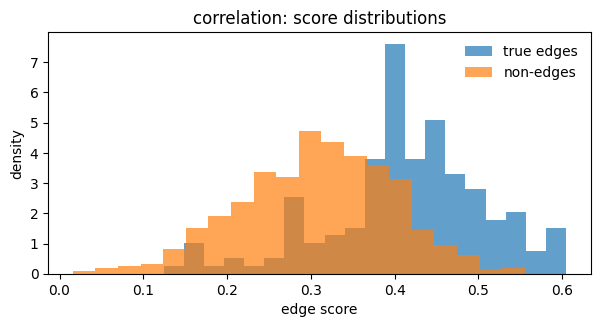

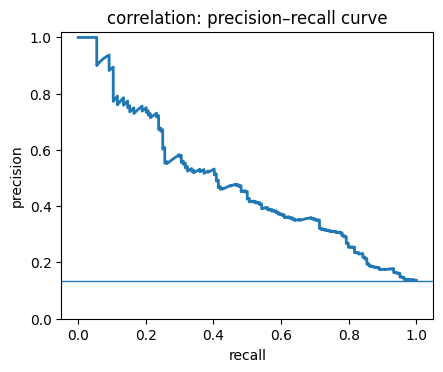

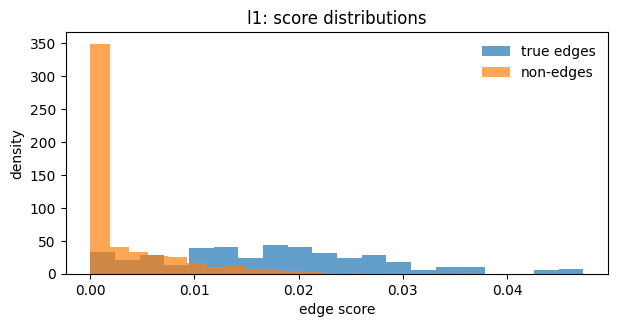

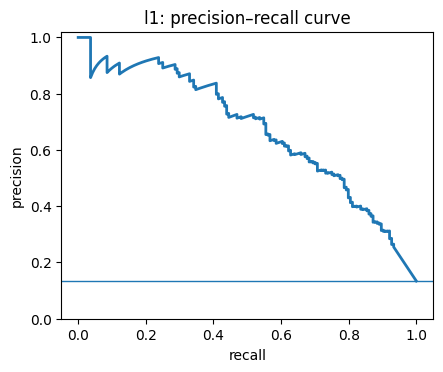

In [45]:
# Visual diagnostics: compare score distributions and PR curves for two methods
for method in ["correlation", "l1"]:
    aux = aux_store[method]
    y_true = aux["y_true"]
    y_score = aux["y_score"]

    plot_score_histogram(y_true, y_score, title=f"{method}: score distributions")
    plot_precision_recall_curve(y_true, y_score, title=f"{method}: precision–recall curve")


## 9. A reconstruction benchmarking harness

A defensible benchmark needs:

- **controlled graph generation** (multiple families, repeated draws),
- **controlled dynamics simulation** (multiple models, repeated runs),
- **consistent reconstruction interfaces** (methods produce score matrices),
- **consistent evaluation** (metrics computed the same way across runs),
- **stress tests** (sample size, noise, partial observation).

We now build a minimal but reusable harness that produces a tidy results table.

### Experimental unit

One benchmark "trial" will be:

1. sample a graph $G$ from a family,  
2. simulate a specified dynamics model on $G$ to obtain observations `obs`,  
3. (optionally) apply observation restrictions (noise, node subsampling),  
4. compute edge scores for each reconstruction method,  
5. evaluate against the ground truth subgraph induced by the observed nodes.

The output is a row in a `pandas.DataFrame` for each (graph, dynamics, method, trial) combination.


In [46]:
def method_is_applicable(method_name, obs):
    """Return True if a method is applicable to this observation type.

    This chapter deliberately mixes dynamics with very different observation models.
    Not every estimator makes sense for every observation:

    - Graphical lasso assumes (approximately) continuous Gaussian data.
    - Event-precedence baselines require event times (infection/adoption times).

    Parameters
    ----------
    method_name : str
        Name passed to `reconstruct_scores`.
    obs : dict
        Observation dict.

    Returns
    -------
    ok : bool
        True if the method can be run without violating its basic data requirements.
    """
    method_name = str(method_name).lower()
    model = obs['model']

    if method_name in ['glasso', 'graphical_lasso'] and is_binary_model(model):
        return False
    if method_name in ['precedence', 'event_precedence', 'cascade_order']:
        return get_event_times(obs) is not None
    return True

def run_benchmark(graph_specs, dynamics_specs, method_specs, n_trials=3,
                  observed_frac=1.0, measurement_noise=0.0, base_seed=0, verbose=True):
    """Run a reconstruction benchmark and return a tidy results DataFrame.

    Parameters
    ----------
    graph_specs : list of dict
        Each dict has keys: 'family', 'n', 'params'.
    dynamics_specs : list of dict
        Each dict has keys: 'model', 'params'.
    method_specs : list of dict
        Each dict has keys: 'method', 'params'.
    n_trials : int
        Repeats per (graph_family, dynamics) combination.
    observed_frac : float
        Fraction of nodes observed (subsampled uniformly at random).
    measurement_noise : float
        Noise level added to observed states.
    base_seed : int
        Global seed offset.
    verbose : bool
        Print progress updates.

    Returns
    -------
    df : pandas.DataFrame
        One row per (trial, graph, dynamics, method) combination.
    """
    rows = []
    trial_counter = 0

    for g_idx, gspec in enumerate(graph_specs):
        fam = gspec['family']
        n = int(gspec['n'])
        gparams = dict(gspec.get('params', {}))

        for trial in range(n_trials):
            seed_graph = int(base_seed + 10000 * g_idx + 97 * trial)
            G, pos, gmeta = generate_graph(fam, n=n, rng_seed=seed_graph, **gparams)
            gdesc = describe_graph(G)

            for d_idx, dspec in enumerate(dynamics_specs):
                model = dspec['model']
                dparams = dict(dspec.get('params', {}))
                seed_dyn = int(base_seed + 10000 * g_idx + 97 * trial + 1000 * d_idx + 13)

                obs = simulate_dynamics(G, model_name=model, params=dparams, rng_seed=seed_dyn)
                obs = subsample_nodes(obs, observed_frac=observed_frac, rng_seed=seed_dyn + 1)
                obs = add_measurement_noise(obs, noise_level=measurement_noise, rng_seed=seed_dyn + 2)

                Xp, Xn = stack_transitions(obs)
                sample_size = int(Xp.shape[0])
                n_obs = int(len(obs['node_order']))

                # Run methods
                for m_idx, mspec in enumerate(method_specs):
                    method = mspec['method']
                    mparams = dict(mspec.get('params', {}))

                    if not method_is_applicable(method, obs):
                        # Record as missing
                        rows.append({
                            "trial": trial,
                            "graph_family": fam,
                            "dynamics": obs['model'],
                            "method": method,
                            "n": n_obs,
                            "m_true": np.nan,
                            "roc_auc": np.nan,
                            "pr_auc": np.nan,
                            "precision_at_k": np.nan,
                            "recall_at_k": np.nan,
                            "f1_at_k": np.nan,
                            "runtime_sec": np.nan,
                            "sample_size": sample_size,
                            "observed_frac": observed_frac,
                            "measurement_noise": measurement_noise,
                            **{f"graph_{k}": v for k, v in gdesc.items()},
                        })
                        continue

                    t0 = time.time()
                    try:
                        S, details = reconstruct_scores(obs, method, **mparams)
                        runtime = time.time() - t0

                        metrics, _ = evaluate_edge_scores(S, G_true=G, node_order=obs['node_order'])
                        row = {
                            "trial": trial,
                            "graph_family": fam,
                            "dynamics": obs['model'],
                            "method": method,
                            **metrics,
                            "runtime_sec": runtime,
                            "sample_size": sample_size,
                            "observed_frac": observed_frac,
                            "measurement_noise": measurement_noise,
                            **{f"graph_{k}": v for k, v in gdesc.items()},
                        }

                        # Attach a few key parameter summaries for readability
                        row["dyn_params"] = str(obs.get('params', {}))
                        row["method_params"] = str(mparams)

                        rows.append(row)

                    except Exception as e:
                        runtime = time.time() - t0
                        rows.append({
                            "trial": trial,
                            "graph_family": fam,
                            "dynamics": obs['model'],
                            "method": method,
                            "n": n_obs,
                            "m_true": np.nan,
                            "roc_auc": np.nan,
                            "pr_auc": np.nan,
                            "precision_at_k": np.nan,
                            "recall_at_k": np.nan,
                            "f1_at_k": np.nan,
                            "runtime_sec": runtime,
                            "sample_size": sample_size,
                            "observed_frac": observed_frac,
                            "measurement_noise": measurement_noise,
                            "error": str(e),
                            **{f"graph_{k}": v for k, v in gdesc.items()},
                        })

                trial_counter += 1
                if verbose:
                    print(f"Completed: graph={fam} trial={trial} dynamics={model} (obs n={n_obs}, samples={sample_size})")

    df = pd.DataFrame(rows)
    return df

print("Benchmark harness ready.")


Benchmark harness ready.


In [47]:
# A tiny benchmark run (fast enough for the notebook)
# For more reliable conclusions, increase n, n_trials, and the number of runs/cascades.

graph_specs = [
    {"family": "er", "n": 28, "params": {"k_avg": 5}},
    {"family": "config", "n": 28, "params": {"k_avg": 5, "exponent": 2.5}},
    {"family": "sbm", "n": 28, "params": {"sizes": [14, 14], "p_in": 0.30, "p_out": 0.05}},
    {"family": "geo", "n": 28, "params": {"radius": 0.34}},
]

dynamics_specs = [
    {"model": "linear_diffusion", "params": {"T": 90, "alpha": 0.35, "noise_std": 0.25, "x0_std": 1.0, "n_runs": 2}},
    {"model": "sis", "params": {"T": 80, "beta": 0.25, "mu": 0.12, "init_infected_frac": 0.12, "n_runs": 4}},
    {"model": "voter", "params": {"T": 90, "epsilon": 0.03, "init_p": 0.5, "n_runs": 4}},
    {"model": "threshold", "params": {"T": 20, "phi_low": 0.15, "phi_high": 0.35, "seed_size": 2, "n_cascades": 15}},
]

method_specs = [
    {"method": "correlation", "params": {}},
    # Neighborhood selection: one regularization setting (fast).
    {"method": "l1", "params": {"train_frac": 0.7, "Cs": [0.7], "alphas": [0.02]}},
    # Event-time baseline: meaningful only for threshold cascades here.
    {"method": "precedence", "params": {"tau": 2.0}},
]

t0 = time.time()
df_tiny = run_benchmark(
    graph_specs=graph_specs,
    dynamics_specs=dynamics_specs,
    method_specs=method_specs,
    n_trials=1,
    observed_frac=1.0,
    measurement_noise=0.0,
    base_seed=0,
    verbose=False,
)
print("Elapsed seconds:", time.time() - t0)

df_tiny.head()


Elapsed seconds: 0.7831239700317383


,trial,graph_family,dynamics,method,n,m_true,pair_count,edge_density,roc_auc,pr_auc,...,observed_frac,measurement_noise,graph_n,graph_m,graph_avg_degree,graph_density,graph_avg_clustering,graph_connected,dyn_params,method_params
0,0,er,linear_diffusion,correlation,27,65.0,351.0,0.185185,0.793168,0.491147,...,1.0,0.0,27,65,4.814815,0.185185,0.177719,True,"{'T': 90, 'alpha': 0.35, 'noise_std': 0.25, 'x...",{}
1,0,er,linear_diffusion,l1,27,65.0,351.0,0.185185,0.842335,0.660811,...,1.0,0.0,27,65,4.814815,0.185185,0.177719,True,"{'T': 90, 'alpha': 0.35, 'noise_std': 0.25, 'x...","{'train_frac': 0.7, 'Cs': [0.7], 'alphas': [0...."
2,0,er,linear_diffusion,precedence,27,NaN,NaN,NaN,NaN,NaN,...,1.0,0.0,27,65,4.814815,0.185185,0.177719,True,NaN,NaN
3,0,er,sis,correlation,27,65.0,351.0,0.185185,0.576116,0.225821,...,1.0,0.0,27,65,4.814815,0.185185,0.177719,True,"{'T': 80, 'beta': 0.25, 'mu': 0.12, 'init_infe...",{}
4,0,er,sis,l1,27,65.0,351.0,0.185185,0.563206,0.217028,...,1.0,0.0,27,65,4.814815,0.185185,0.177719,True,"{'T': 80, 'beta': 0.25, 'mu': 0.12, 'init_infe...","{'train_frac': 0.7, 'Cs': [0.7], 'alphas': [0...."


In [48]:
# League table: mean PR-AUC by (method, dynamics, graph family)
summary = (
    df_tiny
    .groupby(["graph_family", "dynamics", "method"], as_index=False)
    .agg(pr_auc_mean=("pr_auc", "mean"),
         roc_auc_mean=("roc_auc", "mean"),
         runtime_mean=("runtime_sec", "mean"))
)

# Pivot into a league-table style matrix
league = summary.pivot_table(
    index=["graph_family", "dynamics"],
    columns="method",
    values="pr_auc_mean"
)

league


method                         correlation        l1  precedence
graph_family dynamics                                           
config       linear_diffusion     0.445389  0.591895         NaN
             sis                  0.208411  0.163752         NaN
             threshold            0.301261  0.926008    0.539233
             voter                0.883178  0.583174         NaN
er           linear_diffusion     0.491147  0.660811         NaN
             sis                  0.225821  0.217028         NaN
             threshold            0.602931  0.848111    0.551357
             voter                0.829919  0.521544         NaN
geo          linear_diffusion     0.476517  0.617020         NaN
             sis                  0.271926  0.220094         NaN
             threshold            0.836005  0.772444    0.504532
             voter                0.897462  0.637317         NaN
sbm          linear_diffusion     0.452905  0.817632         NaN
             sis                  0.264336  0.228715         NaN
             threshold            0.514649  0.830226    0.596103
             voter                0.854952  0.610969         NaN

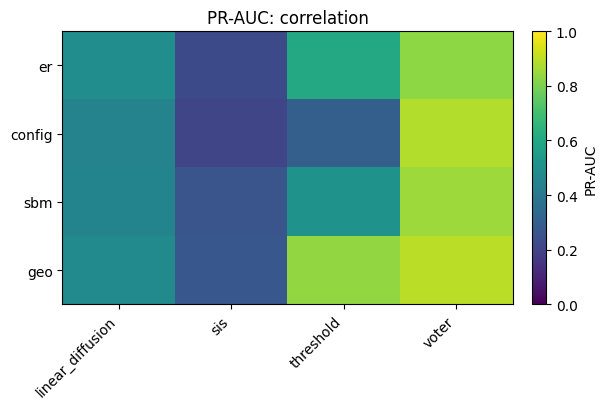

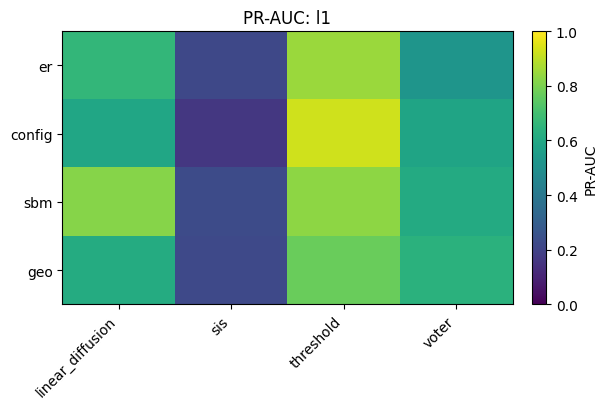

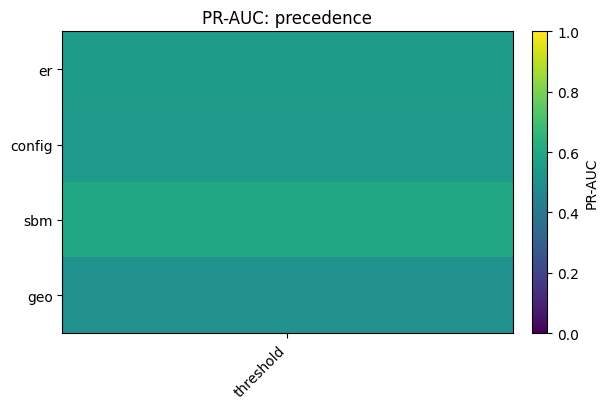

In [49]:
# Visualize PR-AUC as a heatmap (one figure per method)
methods = sorted(df_tiny['method'].unique())

for method in methods:
    mat = summary[summary['method'] == method].pivot_table(
        index="graph_family", columns="dynamics", values="pr_auc_mean"
    ).reindex(index=["er", "config", "sbm", "geo"])

    fig, ax = new_fig(figsize=(6.2, 4.2), dpi=100)
    im = ax.imshow(mat.values, vmin=0.0, vmax=1.0, aspect='auto')
    ax.set_title(f"PR-AUC: {method}")
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=45, ha='right')
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(mat.index)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("PR-AUC")

    plt.tight_layout()
    plt.show()


Even in this tiny benchmark, you can often see qualitative differences:

- **Dynamics matters**: a method that performs well for linear diffusion may struggle for threshold cascades, and vice versa.
- **Graph family matters**: degree heterogeneity, communities, and spatial structure change both the dynamics and the inference difficulty.
- **Method assumptions matter**: the precedence score is only meaningful when event-time information exists; regression-based methods use conditional dependence rather than pairwise similarity.

Do not over-interpret the specific numbers in the table above: the networks are small and there is only one trial per condition. The point is the *workflow*. For serious benchmarking, increase:

- number of trials,
- $n$,
- time horizon $T$ / number of runs,
- and include parameter sweeps for each dynamics model.


In [50]:
def run_sensitivity(G, dynamics_model, base_dyn_params, vary_key, vary_values,
                    methods, method_params=None, base_seed=0, measurement_noise=0.0, observed_frac=1.0):
    """Run a one-factor sensitivity experiment for a fixed graph and dynamics."""
    if method_params is None:
        method_params = {m: {} for m in methods}

    rows = []
    for idx, val in enumerate(vary_values):
        dyn_params = dict(base_dyn_params)
        dyn_params[vary_key] = val

        obs = simulate_dynamics(G, model_name=dynamics_model, params=dyn_params, rng_seed=base_seed + 100 * idx)
        obs = subsample_nodes(obs, observed_frac=observed_frac, rng_seed=base_seed + 100 * idx + 1)
        obs = add_measurement_noise(obs, noise_level=measurement_noise, rng_seed=base_seed + 100 * idx + 2)

        Xp, _ = stack_transitions(obs)
        sample_size = Xp.shape[0]

        for m in methods:
            params = dict(method_params.get(m, {}))
            t0 = time.time()
            S, _ = reconstruct_scores(obs, m, **params)
            runtime = time.time() - t0

            metrics, _ = evaluate_edge_scores(S, G_true=G, node_order=obs['node_order'])
            rows.append({
                vary_key: val,
                "method": m,
                "pr_auc": metrics["pr_auc"],
                "roc_auc": metrics["roc_auc"],
                "precision_at_k": metrics["precision_at_k"],
                "runtime_sec": runtime,
                "sample_size": sample_size,
                "measurement_noise": measurement_noise,
                "observed_frac": observed_frac,
            })

    return pd.DataFrame(rows)


In [51]:
# Sensitivity 1: sample size via number of runs (linear diffusion)
G_test, _, _ = generate_graph("sbm", n=35, rng_seed=10, sizes=[18,17], p_in=0.25, p_out=0.03)

base_dyn = {"T": 120, "alpha": 0.35, "noise_std": 0.22, "x0_std": 1.0, "n_runs": 2}
vary_runs = [1, 2, 4, 8]

methods = ["correlation", "l1"]
method_params = {
    "correlation": {},
    "l1": {"train_frac": 0.7, "alphas": [0.02], "Cs": [0.7]},
}

df_samp = run_sensitivity(
    G_test, "linear_diffusion", base_dyn_params=base_dyn,
    vary_key="n_runs", vary_values=vary_runs,
    methods=methods, method_params=method_params,
    base_seed=0
)

df_samp


,n_runs,method,pr_auc,roc_auc,precision_at_k,runtime_sec,sample_size,measurement_noise,observed_frac
0,1,correlation,0.299720,0.638415,0.290698,0.000298,119,0.0,1.0
1,1,l1,0.401314,0.718132,0.372093,0.020455,119,0.0,1.0
2,2,correlation,0.357791,0.731667,0.348837,0.000191,238,0.0,1.0
3,2,l1,0.658569,0.878455,0.616279,0.018188,238,0.0,1.0
4,4,correlation,0.683950,0.912254,0.662791,0.000220,476,0.0,1.0
5,4,l1,0.902568,0.973317,0.837209,0.029400,476,0.0,1.0
6,8,correlation,0.784237,0.951387,0.744186,0.000291,952,0.0,1.0
7,8,l1,0.992537,0.998675,0.941860,0.042102,952,0.0,1.0


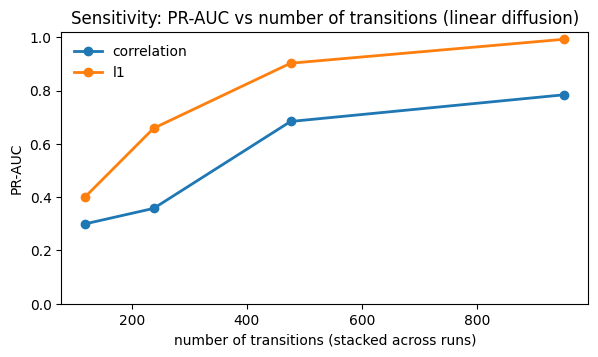

In [52]:
# Plot PR-AUC vs sample size
fig, ax = new_fig(figsize=(6.8, 3.6))
for method in df_samp["method"].unique():
    sub = df_samp[df_samp["method"] == method].sort_values("n_runs")
    ax.plot(sub["sample_size"], sub["pr_auc"], marker="o", lw=2, label=method)

ax.set_title("Sensitivity: PR-AUC vs number of transitions (linear diffusion)")
ax.set_xlabel("number of transitions (stacked across runs)")
ax.set_ylabel("PR-AUC")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False)
plt.show()


In [53]:
# Sensitivity 2: measurement noise (bit flips) for SIS
G_test2, _, _ = generate_graph("config", n=35, rng_seed=11, k_avg=6, exponent=2.5)

dyn_sis = {"T": 100, "beta": 0.23, "mu": 0.10, "init_infected_frac": 0.10, "n_runs": 8}
noise_levels = [0.0, 0.01, 0.03, 0.06, 0.10]

rows = []
for idx, nl in enumerate(noise_levels):
    obs = simulate_dynamics(G_test2, model_name="sis", params=dyn_sis, rng_seed=100 + idx)
    obs = add_measurement_noise(obs, noise_level=nl, rng_seed=200 + idx)

    Xp, _ = stack_transitions(obs)
    sample_size = Xp.shape[0]

    for method in ["correlation", "l1"]:
        if method == "l1":
            S, _ = reconstruct_scores(obs, method, train_frac=0.7, Cs=[0.7], alphas=[0.02])
        else:
            S, _ = reconstruct_scores(obs, method)

        metrics, _ = evaluate_edge_scores(S, G_true=G_test2, node_order=obs["node_order"])
        rows.append({
            "measurement_noise": nl,
            "method": method,
            "pr_auc": metrics["pr_auc"],
            "roc_auc": metrics["roc_auc"],
            "precision_at_k": metrics["precision_at_k"],
            "sample_size": sample_size,
        })

df_noise = pd.DataFrame(rows)
df_noise


,measurement_noise,method,pr_auc,roc_auc,precision_at_k,sample_size
0,0.00,correlation,0.387258,0.799372,0.418919,792
1,0.00,l1,0.234304,0.667713,0.256757,792
2,0.01,correlation,0.307953,0.726306,0.283784,792
3,0.01,l1,0.209675,0.645770,0.256757,792
4,0.03,correlation,0.317249,0.747782,0.324324,792
5,0.03,l1,0.220405,0.653123,0.270270,792
6,0.06,correlation,0.226658,0.572677,0.270270,792
7,0.06,l1,0.210633,0.593635,0.202703,792
8,0.10,correlation,0.177568,0.621609,0.216216,792
9,0.10,l1,0.184200,0.583052,0.189189,792


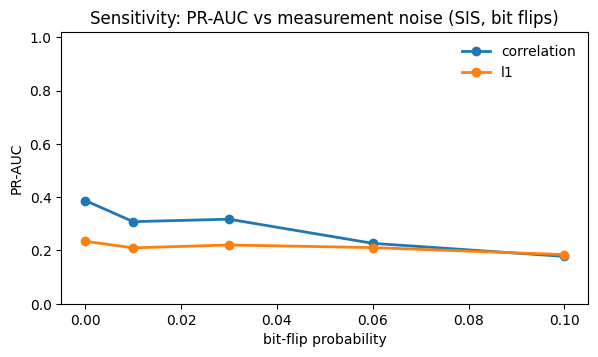

In [54]:
fig, ax = new_fig(figsize=(6.8, 3.6))
for method in df_noise["method"].unique():
    sub = df_noise[df_noise["method"] == method].sort_values("measurement_noise")
    ax.plot(sub["measurement_noise"], sub["pr_auc"], marker="o", lw=2, label=method)

ax.set_title("Sensitivity: PR-AUC vs measurement noise (SIS, bit flips)")
ax.set_xlabel("bit-flip probability")
ax.set_ylabel("PR-AUC")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False)
plt.show()


In [55]:
# Sensitivity 3: partial observation (fraction of nodes observed)
G_test3, _, _ = generate_graph("geo", n=45, rng_seed=12, radius=0.30)

dyn_voter = {"T": 120, "epsilon": 0.03, "init_p": 0.5, "n_runs": 8}
fractions = [0.4, 0.6, 0.8, 1.0]

rows = []
for frac in fractions:
    obs = simulate_dynamics(G_test3, model_name="voter", params=dyn_voter, rng_seed=2)
    obs = subsample_nodes(obs, observed_frac=frac, rng_seed=3)
    for method in ["correlation", "l1"]:
        S, _ = reconstruct_scores(obs, method, train_frac=0.7, Cs=[0.7], alphas=[0.02]) if method == "l1" else reconstruct_scores(obs, method)
        metrics, _ = evaluate_edge_scores(S, G_true=G_test3, node_order=obs["node_order"])
        rows.append({
            "observed_frac": frac,
            "method": method,
            "pr_auc": metrics["pr_auc"],
            "roc_auc": metrics["roc_auc"],
            "n_obs": metrics["n"],
            "m_true": metrics["m_true"],
        })

df_obsfrac = pd.DataFrame(rows)
df_obsfrac


,observed_frac,method,pr_auc,roc_auc,n_obs,m_true
0,0.4,correlation,0.882546,0.980759,18,30
1,0.4,l1,0.740274,0.925745,18,30
2,0.6,correlation,0.938713,0.982047,27,74
3,0.6,l1,0.749686,0.881940,27,74
4,0.8,correlation,0.902977,0.970009,36,152
5,0.8,l1,0.537858,0.762869,36,152
6,1.0,correlation,0.897053,0.973133,45,224
7,1.0,l1,0.521623,0.747284,45,224


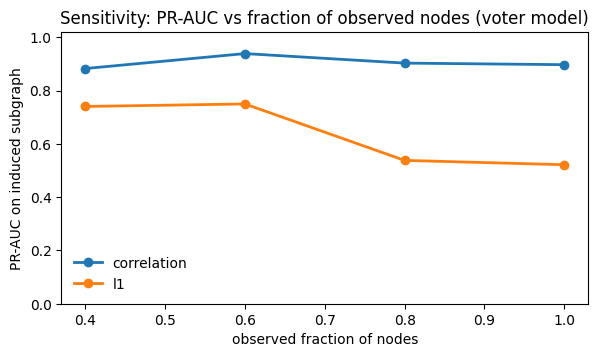

In [56]:
fig, ax = new_fig(figsize=(6.8, 3.6))
for method in df_obsfrac["method"].unique():
    sub = df_obsfrac[df_obsfrac["method"] == method].sort_values("observed_frac")
    ax.plot(sub["observed_frac"], sub["pr_auc"], marker="o", lw=2, label=method)

ax.set_title("Sensitivity: PR-AUC vs fraction of observed nodes (voter model)")
ax.set_xlabel("observed fraction of nodes")
ax.set_ylabel("PR-AUC on induced subgraph")
ax.set_ylim(0, 1.02)
ax.legend(frameon=False)
plt.show()


## 10. Pitfalls, diagnostics, and ways to fool yourself

Reconstruction is one of those tasks where it is easy to get a high-looking number for the wrong reason.

If Class 02 was about thresholding and sparsification when a weighted graph is already in hand, this section is about the **same problem after an inference step**. Many reconstruction methods end by handing us a score matrix rather than a graph, so the thresholding question comes back at the end of the pipeline.

This section collects a few repeat offenders, patterns that show up across domains such as neuroscience, finance, systems biology, and social networks when people turn observations into a graph. The examples are small, but the failure modes scale up.

### 10.1 Thresholding correlation matrices into graphs

A common pipeline, especially in functional-network settings, is:

1. compute a similarity matrix $S$, often a correlation matrix;
2. pick a threshold $\tau$ or target edge density; and
3. define an unweighted graph by $A_{ij} = 1\{S_{ij} \ge \tau\}$.

This is tempting because it is simple and yields an object you can feed into any network-science toolbox. But several things can go wrong:

- **Indirect paths and common drivers** mean that correlation does not isolate direct interactions.
- **Threshold choice is an extra modeling decision.** Many network metrics vary wildly with density.
- **Dependence between edges is structural.** Correlation matrices and other relational data sets have constraints that make thresholded graphs behave in nontrivial ways.
- **Statistical significance is not the same thing as direct connection.** A significant correlation can be produced by a latent factor.

Cantwell et al. (2020) provide a particularly sharp warning: even if the underlying edge weights are simple Gaussian variables with local correlations between adjacent edges, thresholding can generate networks with heavy-tailed degrees, clustering, and percolation behavior that look "complex" even though the generative ingredients were not.

Below are two small demonstrations:

- a latent-factor time-series example, where thresholding a correlation matrix manufactures structure; and
- a direct implementation of the locally correlated edge-weight model studied by Cantwell et al. (2020), often called ThredgeCorr.


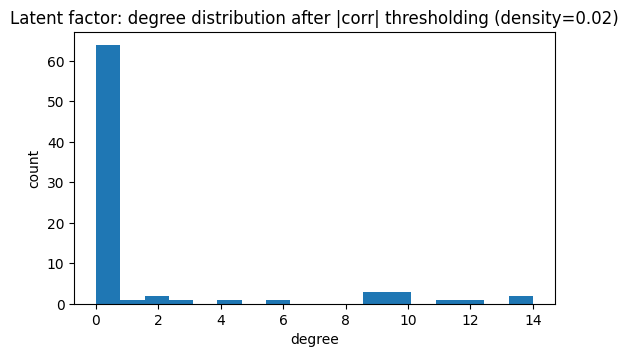

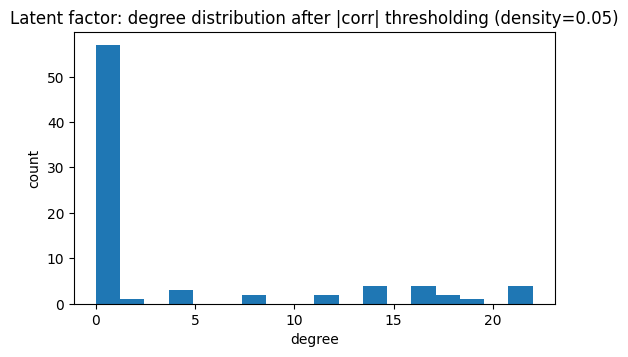

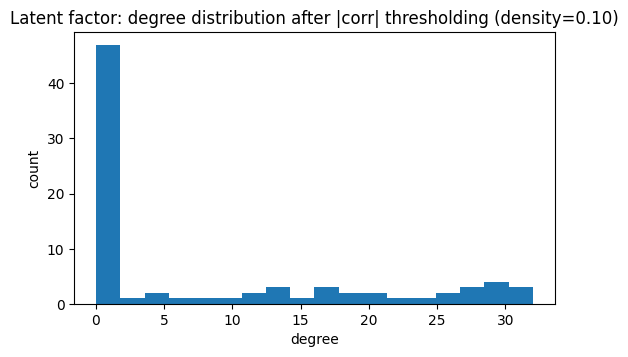

,density,threshold,avg_degree,clustering,lcc_size
0,0.02,0.759822,1.575,0.164918,16
1,0.05,0.687872,3.950,0.254960,24
2,0.10,0.614495,7.900,0.360349,33


In [57]:
def threshold_by_density(W, density):
    """Threshold a symmetric weight matrix by keeping a fixed edge density.

    Parameters
    ----------
    W : array, shape (n, n)
        Symmetric weights with zeros on the diagonal (e.g., |correlation|).
    density : float
        Fraction of all possible undirected edges to keep, in (0, 1].

    Returns
    -------
    A : array, shape (n, n)
        Binary adjacency matrix after thresholding.
    thresh : float
        The weight threshold used (edges with weight >= thresh are kept).
    """
    W = np.asarray(W, dtype=float)
    n = W.shape[0]
    w, iu = vectorize_upper_triangle(W)

    m = int(np.floor(float(density) * len(w)))
    m = max(1, min(m, len(w)))

    thresh = np.partition(w, -m)[-m]
    keep = (w >= thresh).astype(int)

    A = np.zeros((n, n), dtype=int)
    A[iu] = keep
    A = A + A.T
    np.fill_diagonal(A, 0)
    return A, float(thresh)


def bh_fdr(pvals, q=0.05):
    """Benjamini–Hochberg FDR threshold for a 1D array of p-values.

    Returns the largest p* such that p_(k) <= (k/m) q, where p_(k) is the k-th smallest
    p-value and m is the number of tests. If no p-values pass, returns 0.

    Parameters
    ----------
    pvals : array-like
        Collection of p-values in [0, 1].
    q : float
        Target false discovery rate.

    Returns
    -------
    p_star : float
        Rejection threshold. Reject all hypotheses with p <= p_star.
    """
    p = np.asarray(pvals, dtype=float)
    p = p[np.isfinite(p)]
    m = p.size
    if m == 0:
        return 0.0

    order = np.argsort(p)
    p_sorted = p[order]
    thresh = (np.arange(1, m + 1) / m) * float(q)
    passed = np.where(p_sorted <= thresh)[0]

    if passed.size == 0:
        return 0.0

    return float(p_sorted[passed.max()])


def correlation_pvalues(C, T):
    r"""Approximate two-sided p-values for Pearson correlations using Fisher z-transform.

    Under the null hypothesis of zero correlation, for large-ish T:

    $$

    z = \operatorname{atanh}(r)\,\sqrt{T-3} \approx \mathcal{N}(0,1).

    $$

    Parameters
    ----------
    C : array, shape (n, n)
        Sample correlation matrix.
    T : int
        Number of time points used to compute C.

    Returns
    -------
    P : array, shape (n, n)
        Two-sided p-values for each entry, with zeros on the diagonal.
    """
    C = np.asarray(C, dtype=float)
    n = C.shape[0]

    R = np.clip(C, -0.999999, 0.999999)
    Z = np.arctanh(R) * np.sqrt(max(T - 3, 1))
    P = 2.0 * norm.sf(np.abs(Z))
    np.fill_diagonal(P, 0.0)
    return P


# -------------------------------------------------------------------
# Demo 1:# -------------------------------------------------------------------
# Demo 1: latent-factor time series -> correlation matrix -> thresholded graph
# -------------------------------------------------------------------
rng_latent = make_rng(123)

n_latent = 80
T_latent = 600

# Latent factor z(t) drives all nodes with heterogeneous loadings a_i.
z = rng_latent.normal(size=T_latent)
a = rng_latent.normal(size=n_latent)

X_latent = a[None, :] * z[:, None] + rng_latent.normal(scale=1.0, size=(T_latent, n_latent))

C_latent = np.corrcoef(X_latent, rowvar=False)
np.fill_diagonal(C_latent, 0.0)
W_latent = np.abs(C_latent)

densities = [0.02, 0.05, 0.10]
rows = []

for dens in densities:
    A, thr = threshold_by_density(W_latent, dens)
    Gt = nx.from_numpy_array(A)

    deg = np.array([d for _, d in Gt.degree()], dtype=int)
    cc = float(np.mean(list(nx.clustering(Gt).values())))
    lcc = max((len(c) for c in nx.connected_components(Gt)), default=0)

    rows.append(dict(density=dens, threshold=thr, avg_degree=float(deg.mean()), clustering=cc, lcc_size=lcc))

    fig, ax = new_fig(figsize=(6.2, 3.6), dpi=100)
    ax.hist(deg, bins=18)
    ax.set_title(f"Latent factor: degree distribution after |corr| thresholding (density={dens:.2f})")
    ax.set_xlabel("degree")
    ax.set_ylabel("count")
    plt.show()

df_corr_thresh = pd.DataFrame(rows)
df_corr_thresh


A common suggestion is to threshold correlations by *statistical significance* rather than by density. Significance testing is useful for controlling false positives under a null model, but it does not solve confounding: in the latent-factor example above, many correlations are "real" (the common driver really does induce dependence), yet there is no underlying structural edge.

Still, significance thresholding is worth understanding because it appears frequently in applied work. A standard approximation uses Fisher's $z$-transform (as implemented below) and then corrects for multiple comparisons using a false discovery rate procedure.


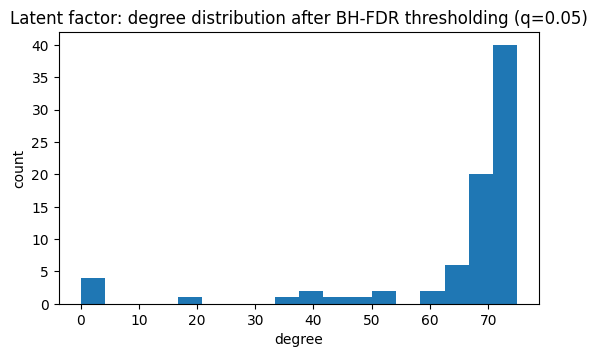

FDR threshold p* = 0.0400192292199506
Edges kept        = 2580 out of 3160
Avg degree        = 64.5


In [58]:
# Significance-based thresholding on the same latent-factor data

P = correlation_pvalues(C_latent, T=T_latent)
pvals, iu = vectorize_upper_triangle(P)

p_star = bh_fdr(pvals, q=0.05)

A_sig = np.zeros((n_latent, n_latent), dtype=int)
A_sig[iu] = (pvals <= p_star).astype(int)
A_sig = A_sig + A_sig.T
np.fill_diagonal(A_sig, 0)

G_sig = nx.from_numpy_array(A_sig)
deg_sig = np.array([d for _, d in G_sig.degree()], dtype=int)

fig, ax = new_fig(figsize=(6.2, 3.6), dpi=100)
ax.hist(deg_sig, bins=18)
ax.set_title("Latent factor: degree distribution after BH-FDR thresholding (q=0.05)")
ax.set_xlabel("degree")
ax.set_ylabel("count")
plt.show()

print("FDR threshold p* =", p_star)
print("Edges kept        =", G_sig.number_of_edges(), "out of", n_latent*(n_latent-1)//2)
print("Avg degree        =", deg_sig.mean())


The next example follows the *edge-weight* model in Cantwell et al. (2020). The idea is to generate a complete weighted graph where the edge weights are Gaussian, but **adjacent edges share correlation** (edges incident to the same node tend to move together). Then we threshold those weights to get an unweighted graph.

This is a "null model" for an important warning:

> if you start from relational data with local correlations between edge weights, thresholding alone can manufacture heavy-tailed degrees and clustering.

In Cantwell et al. (2020), the parameter is often written as an *edge covariance* $c$ with $0\le c \le 1/2$. When $c=0$, edges are independent (classic thresholded Erdős–Rényi behavior). As $c$ increases, the resulting thresholded graphs become progressively more heterogeneous.

We implement the same sampling rule used in the open-source ThredgeCorr code base.


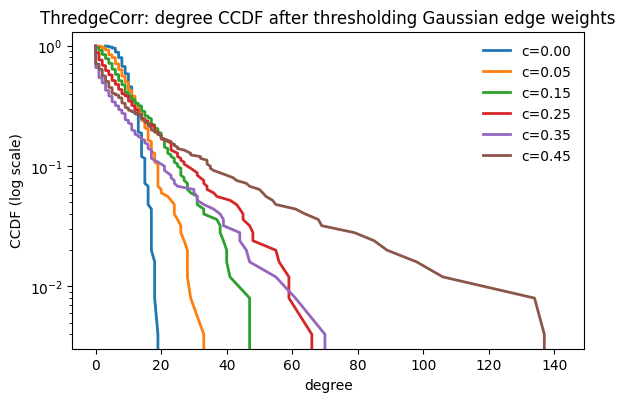

,covariance,avg_degree,clustering,lcc_size
0,0.00,10.448,0.046750,250
1,0.05,10.704,0.066727,250
2,0.15,11.248,0.139996,243
3,0.25,11.016,0.243753,220
4,0.35,7.288,0.228293,165
5,0.45,12.528,0.552061,177


In [59]:
def sample_thredgecorr_adjacency(n, covariance=0.0, mean_degree=8.0, rng_seed=0):
    """Sample a thresholded locally-correlated edge-weight network (ThredgeCorr).

    This implements the construction from Cantwell et al. (2020) and the accompanying
    ThredgeCorr reference code:

    - Draw latent node variables z_i ~ N(0,1)
    - For each undirected edge (i,j), sample

        w_ij = a * y_ij + b * (z_i + z_j),

      where y_ij ~ N(0,1), a = sqrt(1 - 2c), b = sqrt(c), and c is the covariance.

    - Threshold: keep edge if w_ij > t, where t is chosen so that E[deg] = mean_degree
      under a standard normal marginal.

    Parameters
    ----------
    n : int
        Number of nodes.
    covariance : float
        Edge covariance parameter c in [0, 1/2]. Larger values create stronger
        local correlations between adjacent edge weights.
    mean_degree : float
        Target expected degree after thresholding.
    rng_seed : int
        RNG seed.

    Returns
    -------
    A : array, shape (n, n)
        Binary adjacency matrix.
    info : dict
        Dictionary containing the threshold and parameters used.
    """
    c = float(covariance)
    if c < 0 or c > 0.5:
        raise ValueError("covariance must be in [0, 0.5].")

    rng = make_rng(rng_seed)

    p = float(mean_degree) / float(n - 1)
    p = min(max(p, 1e-9), 1 - 1e-9)
    t = float(norm.isf(p))

    z = rng.normal(size=n)
    a = np.sqrt(max(1.0 - 2.0 * c, 0.0))
    b = np.sqrt(c)

    A = np.zeros((n, n), dtype=int)
    for i in range(n - 1):
        y = rng.normal(size=(n - 1 - i))
        w = a * y + b * (z[i] + z[i + 1 :])
        keep = np.where(w > t)[0]
        if keep.size > 0:
            js = (i + 1 + keep).astype(int)
            A[i, js] = 1
            A[js, i] = 1

    return A, dict(n=n, covariance=c, mean_degree=float(mean_degree), threshold=t)


covariances = [0.0, 0.05, 0.15, 0.25, 0.35, 0.45]
n_demo = 250
k_demo = 10

rows = []
fig, ax = new_fig(figsize=(6.6, 4.2), dpi=100)

for c in covariances:
    A, info = sample_thredgecorr_adjacency(n_demo, covariance=c, mean_degree=k_demo, rng_seed=int(10 + 1000 * c))
    Gc = nx.from_numpy_array(A)
    deg = np.array([d for _, d in Gc.degree()], dtype=float)

    # CCDF for degrees
    xs = np.sort(deg)
    ccdf = 1.0 - np.arange(1, len(xs) + 1) / len(xs)

    ax.plot(xs, ccdf, lw=2, label=f"c={c:.2f}")

    rows.append(dict(
        covariance=c,
        avg_degree=float(deg.mean()),
        clustering=float(np.mean(list(nx.clustering(Gc).values()))),
        lcc_size=max((len(comp) for comp in nx.connected_components(Gc)), default=0)
    ))

ax.set_yscale("log")
ax.set_title("ThredgeCorr: degree CCDF after thresholding Gaussian edge weights")
ax.set_xlabel("degree")
ax.set_ylabel("CCDF (log scale)")
ax.legend(frameon=False)
plt.show()

pd.DataFrame(rows)


### 10.2 Micro-example: partial correlation removes a common driver (under Gaussian assumptions)

For a multivariate Gaussian model, the **precision matrix** $\Theta = \Sigma^{-1}$, the inverse covariance, encodes conditional dependence. The partial correlation between variables $i$ and $j$ given all others is

$$
\rho_{ij\mid \text{others}} = -\frac{\Theta_{ij}}{\sqrt{\Theta_{ii}\,\Theta_{jj}}}.
$$

If $\rho_{ij\mid \text{others}} \approx 0$, then in the Gaussian setting variables $i$ and $j$ are conditionally independent given the others, suggesting no direct edge in a Gaussian graphical model.

In the code below, `Sigma` stores $\Sigma$, `Theta` stores $\Theta$, and `P` stores the resulting partial-correlation matrix.

In our toy system, $x_1$ and $x_2$ are both driven by $x_0$, but there is no direct interaction between $x_1$ and $x_2$. Pairwise correlation suggests a spurious $1$–$2$ edge, while partial correlation conditioned on $x_0$ should be much smaller.


In [60]:
# Partial correlation for the toy common-input system

Sigma = np.cov(X, rowvar=False)

# For a well-conditioned covariance, the inverse exists.
# (For real data you often need regularization.)
Theta = np.linalg.inv(Sigma)


def partial_corr_from_precision(Theta):
    """Convert a precision matrix into a partial correlation matrix.

    For a multivariate Gaussian model with covariance Σ and precision Θ = Σ^{-1},
    the partial correlation between variables i and j given all others is:

        ρ_{ij|others} = -Θ_{ij} / sqrt(Θ_{ii} Θ_{jj})

    Parameters
    ----------
    Theta : array, shape (n, n)
        Symmetric precision matrix (inverse covariance).

    Returns
    -------
    P : array, shape (n, n)
        Partial correlation matrix with ones on the diagonal.
    """
    Theta = np.asarray(Theta, dtype=float)
    d = np.sqrt(np.diag(Theta))
    P = -Theta / np.outer(d, d)
    np.fill_diagonal(P, 1.0)
    return P


P = partial_corr_from_precision(Theta)

print("Pearson corr(1,2)       =", corr[1, 2])
print("Partial corr(1,2 | 0)   =", P[1, 2])
print("In this toy example, conditioning on x0 removes most of the spurious 1–2 association.")


Pearson corr(1,2)       = 0.4739762388888955
Partial corr(1,2 | 0)   = 0.02818638309836071
In this toy example, conditioning on x0 removes most of the spurious 1–2 association.


## 11. Scaling and runtime

Reconstruction is often limited by computation:

- Pairwise measures (correlation, mutual information) typically scale like $O(n^2 T)$ because they examine all pairs of nodes.
- Neighborhood selection scales like $O(n)$ regression problems, each with $n$ predictors. The cost depends on solver choice and regularization, but naive implementations can approach $O(n^3)$ behavior in practice.
- Graphical lasso and other inverse-covariance methods involve repeated matrix operations that can be expensive for large $n$.

The exact constants matter: for classroom-sized problems ($n \approx 20$ to $100$), many methods are feasible, but at $n \approx 10^4$ you need very different strategies (sparse solvers, screening rules, distributed computation, etc.).

Below is a small runtime check for our implementations.


In [61]:
# Small runtime benchmark (illustrative, not a formal performance test)

n_list = [20, 30, 40]
methods_rt = [
    ("correlation", {}),
    ("lagged_correlation", {}),
    ("l1", {"train_frac": 0.7, "alphas": [0.02], "Cs": [0.7]}),  # one hyperparameter
    ("graphical_lasso", {"alpha": 0.05}),
]

rows = []
for n in n_list:
    G, _, _ = generate_graph("er", n=n, rng_seed=100 + n, k_avg=6)
    obs = simulate_dynamics(G, "linear_diffusion", params={"T": 110, "alpha": 0.35, "noise_std": 0.22, "x0_std": 1.0, "n_runs": 2}, rng_seed=200 + n)

    for method, params in methods_rt:
        # Skip glasso if n too small? (it works, but included anyway)
        t0 = time.time()
        S, _ = reconstruct_scores(obs, method, **params)
        runtime = time.time() - t0
        metrics, _ = evaluate_edge_scores(S, G_true=G, node_order=obs["node_order"])
        rows.append({
            "n": n,
            "method": method,
            "runtime_sec": runtime,
            "pr_auc": metrics["pr_auc"],
        })

df_rt = pd.DataFrame(rows)
df_rt


,n,method,runtime_sec,pr_auc
0,20,correlation,0.000173,0.562093
1,20,lagged_correlation,0.000172,0.611371
2,20,l1,0.015521,0.729136
3,20,graphical_lasso,0.007844,0.619482
4,30,correlation,0.000141,0.430011
5,30,lagged_correlation,0.000249,0.504931
6,30,l1,0.014169,0.622780
7,30,graphical_lasso,0.005870,0.414145
8,40,correlation,0.000150,0.366175
9,40,lagged_correlation,0.000292,0.424214


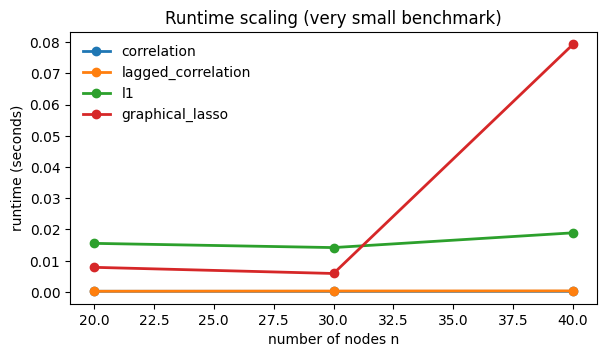

In [62]:
fig, ax = new_fig(figsize=(6.8, 3.6))
for method in df_rt["method"].unique():
    sub = df_rt[df_rt["method"] == method].sort_values("n")
    ax.plot(sub["n"], sub["runtime_sec"], marker="o", lw=2, label=method)

ax.set_title("Runtime scaling (very small benchmark)")
ax.set_xlabel("number of nodes n")
ax.set_ylabel("runtime (seconds)")
ax.legend(frameon=False)
plt.show()


## 12. Whole pipeline!

When you design a reconstruction study (synthetic or real), aim for a workflow like this:

1. **State the inference target**  
   Structural edges? Functional dependence? Directed effective connectivity? Be explicit.

2. **Write down a forward model**  
   Even if you do not fully believe it, write the assumed relationship between neighbors and observations.

3. **Assess identifiability qualitatively**  
   Ask: what symmetries, confounders, or degeneracies might make $A$ underdetermined under this observation model?

4. **Choose at least one baseline and one model-based method**  
   Baselines (correlation) are essential for sanity checks. Model-based methods encode assumptions that can improve recovery.

5. **Tune without using ground-truth edges**  
   Use predictive criteria (held-out forecasting error, held-out likelihood) rather than optimizing ROC/PR directly.

6. **Evaluate with metrics matched to the task**  
   - Use PR-AUC and top-$k$ summaries for sparse graphs.  
   - Report uncertainty via repeated trials or bootstrap resampling.

7. **Stress test**  
   Vary: sample size, noise, observed-node fraction, dynamics parameters. If results are brittle, say so.

8. **Report failure modes**  
   Reconstruction is as much about *knowing when you cannot infer the network* as about showing success.


### 12.1 From synthetic benchmarks to real data

This chapter focused on synthetic benchmarks because ground truth is known. Real data introduces additional modeling layers. Common data types and what you must assume to connect them to edges include:

- **Contact traces / proximity logs** (Bluetooth, RFID), which require assumptions about measurement error, sampling, and whether "contact" equals "transmission opportunity."
- **Information cascades** (retweets, shares, citations), which require an influence or diffusion model and careful handling of exogenous exposures such as mass media or recommendation systems.
- **Neural recordings** (spike trains, calcium imaging), which require a model connecting synaptic coupling to observed activity; unobserved neurons create latent confounding.
- **Gene expression time series**, which require regulatory dynamics models and often strong sparsity assumptions; interventions are especially valuable.
- **Economic or financial time series**, which require careful definitions of causality and confounding; nonstationarity is often the main obstacle.

In all of these settings, it helps to separate:

- the **measurement model**, meaning how raw data becomes node states or events, and
- the **interaction model**, meaning how neighbors influence those states or events.

Reconstruction sits at the interface between those two choices.


## 13. Beyond this chapter: advanced topics and further reading

The standard scientific Python stack can take you surprisingly far, but several important reconstruction directions are beyond what we implemented here.

### 13.1 Likelihood-based diffusion network inference from cascades

For event-time observations (infection/adoption times), there is a large literature on fitting diffusion-network models by maximum likelihood. Representative examples include NetInf and NetRate-style approaches (Gómez-Rodríguez, Leskovec, and Krause, 2010; Gómez-Rodríguez, Balduzzi, and Schölkopf, 2011). These models aim to infer which edges best explain observed cascades under specified transmission time distributions.

### 13.2 Compressive-sensing and sparse recovery perspectives

Several papers frame reconstruction as sparse recovery: the network is sparse, and time-series observations provide linear or linearized constraints that can be solved with $\ell_1$ methods. A well-known example is work by Wang and collaborators on compressive-sensing-based reconstruction of complex networks (e.g., Wang et al., 2011).

### 13.3 Bayesian/MDL approaches and community-aware reconstruction

If you want to reconstruct networks while also capturing structure like communities or hierarchical organization, Bayesian and minimum-description-length approaches are powerful. For example, Peixoto has proposed Bayesian/MDL formulations that unify reconstruction with community detection in dynamical settings (Peixoto, 2019).

### 13.4 Time-varying networks

When edges change over time, reconstruction becomes a much harder problem. One approach is to fit a sequence of sparse inverse covariances with temporal regularization (e.g., Hallac et al., 2017 for a time-varying graphical lasso formulation).

### 13.5 Causality and nonlinearity

Transfer entropy (Schreiber, 2000) and Granger causality (Granger, 1969) are historically important for directed influence in time series. They are best thought of as tools for **effective connectivity** (directed predictive influence), not as guaranteed estimators of a structural interaction graph.

A few points worth keeping straight:

- **Transfer entropy** is a conditional mutual information:


$$

T_{X\to Y} = I\left(Y_{t+1}; X_t^{(k)}\mid Y_t^{(\ell)}\right),

$$

  where $X_t^{(k)}$ denotes a length-$k$ history of $X$ and $Y_t^{(\ell)}$ a length-$\ell$ history of $Y$.

- For **Gaussian variables**, transfer entropy and (linear) Granger causality coincide (Barnett, Barrett, and Seth, 2009). This is useful in practice: it gives a clear baseline estimator, but it also highlights how strongly these methods depend on linear/Gaussian assumptions.

- **Bivariate** Granger/TE is easily fooled by common drivers and indirect paths. Multivariate versions condition on other variables, but that introduces model-selection and finite-sample challenges.

If you want a practical, research-grade implementation of multivariate transfer-entropy-based network inference (including greedy selection of conditioning sets and permutation tests), the IDTxl toolbox is a widely used reference point (Wollstadt et al., 2019). For a broader perspective on causal network reconstruction from time series—assumptions, estimators, and failure modes—see Runge (2018).

### 13.6 Application domains

Reconstruction problems look different depending on the measurement modality:

- **Neuroscience (functional/effective connectivity).** Correlation networks are common, but thresholding and confounding issues are central (Bullmore and Sporns, 2009; Rubinov and Sporns, 2010). Directed influence is often studied via Granger/TE-style tools, among many others.

- **Systems biology (gene regulatory networks).** Popular approaches include information-theoretic methods such as ARACNE (Margolin et al., 2006) and machine-learning approaches such as GENIE3 (Huynh-Thu et al., 2010). Data are often high-dimensional with few samples, so sparsity assumptions and careful validation are essential.

- **Social/information diffusion.** Cascades and event times naturally motivate likelihood-based diffusion-network inference (NetInf/NetRate-style models).

- **Epidemiology.** Contact-network reconstruction from case data is challenging because the observation process (who was tested when, missing asymptomatic infections, reporting delays) interacts with transmission dynamics; strong modeling assumptions are usually unavoidable.

### 13.7 Toolboxes and reproducible benchmarks

A good habit is to separate **scientific questions** from **implementation details** by leaning on well-tested libraries:

- [`netrd`](https://github.com/netsiphd/netrd) is a Python library that implements many network-reconstruction methods and graph-distance measures, useful for baselines and comparisons (McCabe et al., 2021). The official documentation is at <https://netrd.readthedocs.io/>.

- IDTxl (Wollstadt et al., 2019) is a reference implementation for multivariate information-dynamics approaches.

- ThredgeCorr provides code for the thresholded locally correlated edge-weight model used in Cantwell et al. (2020), which is helpful when you want to stress-test "threshold-then-analyze" pipelines.

Even with good tooling, reproducibility hinges on experimental design: fixed seeds, strict train/test splits for tuning, and evaluation on families of synthetic networks and dynamics (not a single hand-picked example).


## Appendix A: Transfer entropy and Granger causality (Gaussian/linear case)

Many "information flow" methods can be intimidating because the general definitions involve conditional mutual information over histories. In one important special case—**linear dynamics with Gaussian noise**—the situation becomes much simpler.

Consider a multivariate VAR(1) model:

$$
x(t+1) = B\,x(t) + \varepsilon(t),
$$

where $x(t)\in\mathbb{R}^n$, $B\in\mathbb{R}^{n\times n}$ is a coefficient matrix, and $\varepsilon(t)$ is i.i.d. Gaussian noise with diagonal covariance.

For this setting:

- a directed edge $j\to i$ corresponds to $B_{ij}\ne 0$ (predictive influence at lag 1), and
- the **Gaussian transfer entropy** from $j$ to $i$ equals a log ratio of residual variances from linear regressions (Barnett, Barrett, and Seth, 2009).

So! If $\sigma^2_{\text{full}}$ is the residual variance when predicting $x_i(t+1)$ from a set of predictors that includes $x_j(t)$, and $\sigma^2_{\text{restricted}}$ is the residual variance when $x_j(t)$ is removed from the predictor set, then

$$
T_{j\to i} = \frac{1}{2}\log\left(\frac{\sigma^2_{\text{restricted}}}{\sigma^2_{\text{full}}}\right).
$$

Below we implement two versions:

- **bivariate** TE/Granger (conditioning only on the target's own past), and  
- **conditional** TE/Granger (conditioning on the past of *all* observed variables).

The conditional version is closer in spirit to toolboxes like IDTxl, which focus on multivariate conditioning to reduce confounding.


spectral radius(B) = 0.95
Directed evaluation (bivariate):   {'roc_auc': 0.9466666666666667, 'pr_auc': 0.8761904761904762, 'edge_density': 0.25}
Directed evaluation (conditional): {'roc_auc': 1.0, 'pr_auc': 1.0, 'edge_density': 0.25}

Top edges (bivariate):
  3 -> 4: 0.1012  (true)
  1 -> 3: 0.05007  (true)
  2 -> 3: 0.04686  (true)
  1 -> 4: 0.04333  
  2 -> 4: 0.03348  
  0 -> 1: 0.02292  (true)
  0 -> 2: 0.02275  (true)
  0 -> 3: 0.02261  

Top edges (conditional):
  3 -> 4: 0.04568  (true)
  1 -> 3: 0.02858  (true)
  2 -> 3: 0.02747  (true)
  0 -> 2: 0.01929  (true)
  0 -> 1: 0.01809  (true)
  4 -> 1: 0.0002088  
  4 -> 2: 0.0001791  
  1 -> 0: 0.0001506  


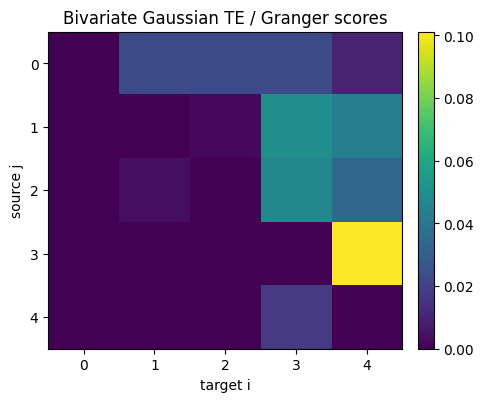

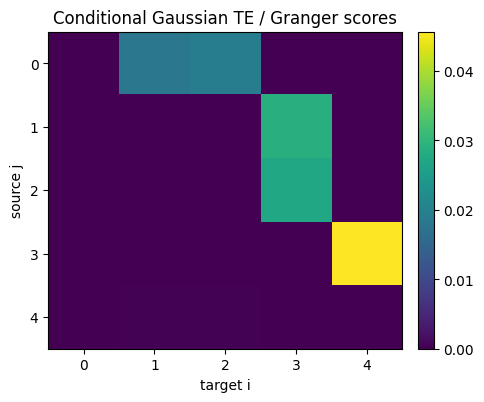

In [63]:
def residual_variance(y, X):
    """Residual variance from an OLS regression with an intercept.

    Parameters
    ----------
    y : array, shape (T,)
        Target.
    X : array, shape (T, p)
        Predictors.

    Returns
    -------
    var : float
        Mean squared residual (using 1/T, not 1/(T-p)).
    """
    y = np.asarray(y, dtype=float).reshape(-1)
    X = np.asarray(X, dtype=float)

    T = y.shape[0]
    if X.ndim == 1:
        X = X.reshape(T, 1)

    # Add intercept
    X1 = np.column_stack([np.ones(T), X])

    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    resid = y - X1 @ beta
    return float(np.mean(resid**2))


def granger_scores_bivariate(X_prev, X_next):
    """Pairwise (bivariate) Gaussian TE/Granger scores at lag 1.

    Predict x_i(t+1) from x_i(t) vs from (x_i(t), x_j(t)).
    """
    X_prev = np.asarray(X_prev, dtype=float)
    X_next = np.asarray(X_next, dtype=float)

    T, n = X_prev.shape
    S = np.zeros((n, n), dtype=float)

    for i in range(n):
        y = X_next[:, i]
        ylag = X_prev[:, i]

        var_restricted = residual_variance(y, ylag)

        for j in range(n):
            if i == j:
                continue
            X_full = np.column_stack([ylag, X_prev[:, j]])
            var_full = residual_variance(y, X_full)

            # Numerical guard
            var_full = max(var_full, 1e-15)
            var_restricted = max(var_restricted, 1e-15)

            S[j, i] = 0.5 * np.log(var_restricted / var_full)

    return np.maximum(S, 0.0)


def granger_scores_conditional(X_prev, X_next):
    """Conditional Gaussian TE/Granger scores at lag 1.

    For each target i, fit a full model using all variables at time t.
    Then remove one source j at a time and recompute residual variance.

    This is a simple multivariate baseline. Practical toolboxes use additional
    structure (lag selection, greedy conditioning, permutation tests, etc.).
    """
    X_prev = np.asarray(X_prev, dtype=float)
    X_next = np.asarray(X_next, dtype=float)

    T, n = X_prev.shape
    S = np.zeros((n, n), dtype=float)

    for i in range(n):
        y = X_next[:, i]

        # Full model uses all variables at time t (including the target's own lag).
        var_full = residual_variance(y, X_prev)
        var_full = max(var_full, 1e-15)

        for j in range(n):
            if i == j:
                continue
            cols = [k for k in range(n) if k != j]
            var_restricted = residual_variance(y, X_prev[:, cols])
            var_restricted = max(var_restricted, 1e-15)

            S[j, i] = 0.5 * np.log(var_restricted / var_full)

    return np.maximum(S, 0.0)


def evaluate_directed_scores(S, A_true):
    """ROC-AUC and PR-AUC for a directed score matrix against a directed adjacency."""
    S = np.asarray(S, dtype=float)
    A_true = np.asarray(A_true, dtype=int)

    n = S.shape[0]
    mask = ~np.eye(n, dtype=bool)
    y_true = A_true[mask].reshape(-1)
    y_score = S[mask].reshape(-1)

    if np.unique(y_true).size < 2:
        return dict(roc_auc=np.nan, pr_auc=np.nan, edge_density=float(np.mean(y_true)))

    return dict(
        roc_auc=float(roc_auc_score(y_true, y_score)),
        pr_auc=float(average_precision_score(y_true, y_score)),
        edge_density=float(np.mean(y_true)),
    )


def top_directed_edges(S, k=10):
    """Return the top-k directed edges (j -> i) by score, excluding self-edges."""
    S = np.asarray(S, dtype=float)
    n = S.shape[0]
    edges = []
    for j in range(n):
        for i in range(n):
            if i == j:
                continue
            edges.append((j, i, S[j, i]))
    edges.sort(key=lambda x: x[2], reverse=True)
    return edges[:k]


# -------------------------------------------------------------------
# A small directed VAR(1) example where bivariate Granger is confounded
# -------------------------------------------------------------------
rng = make_rng(2024)

n = 5
T = 6000
sigma = 0.6

# Ground-truth directed adjacency with a common driver:
# 0 -> {1,2}, then {1,2} -> 3, then 3 -> 4
A_true = np.zeros((n, n), dtype=int)
true_edges = [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4)]
for u, v in true_edges:
    A_true[u, v] = 1

self_c = 0.95
edge_c = 0.08

B = self_c * np.eye(n)
for u, v in true_edges:
    B[v, u] = edge_c

# Quick stability check (spectral radius < 1)
rho = float(np.max(np.abs(np.linalg.eigvals(B))))
print("spectral radius(B) =", rho)

# Simulate
X = np.zeros((T, n), dtype=float)
X[0] = rng.normal(size=n)

for t in range(T - 1):
    X[t + 1] = B @ X[t] + sigma * rng.normal(size=n)

X_prev = X[:-1]
X_next = X[1:]

S_biv = granger_scores_bivariate(X_prev, X_next)
S_cond = granger_scores_conditional(X_prev, X_next)

print("Directed evaluation (bivariate):  ", evaluate_directed_scores(S_biv, A_true))
print("Directed evaluation (conditional):", evaluate_directed_scores(S_cond, A_true))

print("\nTop edges (bivariate):")
for j, i, s in top_directed_edges(S_biv, k=8):
    print(f"  {j} -> {i}: {s:.4g}  {'(true)' if A_true[j,i] else ''}")

print("\nTop edges (conditional):")
for j, i, s in top_directed_edges(S_cond, k=8):
    print(f"  {j} -> {i}: {s:.4g}  {'(true)' if A_true[j,i] else ''}")

fig, ax = new_fig(figsize=(5.0, 4.2), dpi=100)
im = ax.imshow(S_biv, aspect='auto')
ax.set_title("Bivariate Gaussian TE / Granger scores")
ax.set_xlabel("target i")
ax.set_ylabel("source j")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

fig, ax = new_fig(figsize=(5.0, 4.2), dpi=100)
im = ax.imshow(S_cond, aspect='auto')
ax.set_title("Conditional Gaussian TE / Granger scores")
ax.set_xlabel("target i")
ax.set_ylabel("source j")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


## References

**Textbook background**

- Newman, M. (2018). *Networks* (2nd ed.). Oxford University Press. DOI: 10.1093/oso/9780198805090.001.0001  

**Network reconstruction, identifiability, and surveys**

- Angulo, M. T., Liu, Y.-Y., Slotine, J.-J. E., & Barabási, A.-L. (2017). *Fundamental limitations of network reconstruction from temporal data.* Journal of the Royal Society Interface, 14(127), 20160966. DOI: 10.1098/rsif.2016.0966  
- Brugeré, I., Gallagher, B., & Berger-Wolf, T. Y. (2018). *Network structure inference, a survey.* ACM Computing Surveys, 51(2), Article 24 (24:1–24:39). DOI: 10.1145/3154524  
- Timme, M., & Casadiego, J. (2014). *Revealing networks from dynamics: an introduction.* Journal of Physics A: Mathematical and Theoretical, 47(34), 343001. DOI: 10.1088/1751-8113/47/34/343001  
- Runge, J. (2018). *Causal network reconstruction from time series: From theoretical assumptions to practical estimation.* Chaos, 28(7), 075310. DOI: 10.1063/1.5025050  

**Correlation, thresholding, and "functional networks"**

- Cantwell, G. T., Liu, Y., Maier, B. F., Schwarze, A. C., Serván, C. A., Snyder, J., & St-Onge, G. (2020). *Thresholding normally distributed data results in complex networks.* Physical Review E, 101, 062302. DOI: 10.1103/PhysRevE.101.062302  
- van Wijk, B. C. M., Stam, C. J., & Daffertshofer, A. (2010). *Comparing brain networks of different size and connectivity density using graph theory.* PLoS ONE, 5(10), e13701. DOI: 10.1371/journal.pone.0013701  
- Bullmore, E., & Sporns, O. (2009). *Complex brain networks: graph theoretical analysis of structural and functional systems.* Nature Reviews Neuroscience, 10(3), 186–198. DOI: 10.1038/nrn2575  
- Rubinov, M., & Sporns, O. (2010). *Complex network measures of brain connectivity: Uses and interpretations.* NeuroImage, 52(3), 1059–1069. DOI: 10.1016/j.neuroimage.2009.10.003  
- Serrano, M. Á., Boguñá, M., & Vespignani, A. (2009). *Extracting the multiscale backbone of complex weighted networks.* Proceedings of the National Academy of Sciences, 106(16), 6483–6488. DOI: 10.1073/pnas.0808904106  

**Sparse graphical models and conditional dependence**

- Meinshausen, N., & Bühlmann, P. (2006). *High-dimensional graphs and variable selection with the lasso.* The Annals of Statistics, 34(3), 1436–1462. DOI: 10.1214/009053606000000281  
- Ravikumar, P., Wainwright, M. J., Raskutti, G., & Yu, B. (2010). *High-dimensional Ising model selection using $\ell_1$-regularized logistic regression.* The Annals of Statistics, 38(3), 1287–1319. DOI: 10.1214/09-AOS691  
- Friedman, J., Hastie, T., & Tibshirani, R. (2008). *Sparse inverse covariance estimation with the graphical lasso.* Biostatistics, 9(3), 432–441. DOI: 10.1093/biostatistics/kxm045  
- Hallac, D., Park, Y., Boyd, S., & Leskovec, J. (2017). *Network inference via the time-varying graphical lasso.* Proceedings of KDD 2017, 205–213. DOI: 10.1145/3097983.3098037  

**Information-theoretic and causal influence**

- Schreiber, T. (2000). *Measuring information transfer.* Physical Review Letters, 85(2), 461–464. DOI: 10.1103/PhysRevLett.85.461  
- Granger, C. W. J. (1969). *Investigating causal relations by econometric models and cross-spectral methods.* Econometrica, 37(3), 424–438. DOI: 10.2307/1912791  
- Barnett, L., Barrett, A. B., & Seth, A. K. (2009). *Granger causality and transfer entropy are equivalent for Gaussian variables.* Physical Review Letters, 103(23), 238701. DOI: 10.1103/PhysRevLett.103.238701  
- Wollstadt, P., Martínez-Zarzuela, M., Vicente, R., Díaz-Pernas, F. J., & Wibral, M. (2019). *IDTxl: The Information Dynamics Toolkit xl: a Python package for the efficient analysis of multivariate information dynamics in networks.* Journal of Open Source Software, 4(34), 1081. DOI: 10.21105/joss.01081  

**Diffusion, epidemics, cascades, and opinion dynamics**

- Pastor-Satorras, R., & Vespignani, A. (2001). *Epidemic spreading in scale-free networks.* Physical Review Letters, 86(14), 3200–3203. DOI: 10.1103/PhysRevLett.86.3200  
- Watts, D. J. (2002). *A simple model of global cascades on random networks.* Proceedings of the National Academy of Sciences, 99(9), 5766–5771. DOI: 10.1073/pnas.082090499  
- Sood, V., & Redner, S. (2005). *Voter model on heterogeneous graphs.* Physical Review Letters, 94, 178701. DOI: 10.1103/PhysRevLett.94.178701  
- Shen, Z., Wang, W.-X., Fan, Y., Di, Z., & Lai, Y.-C. (2014). *Reconstructing propagation networks with natural diversity and identifying hidden sources.* Nature Communications, 5, 4323. DOI: 10.1038/ncomms5323  

**Reconstruction algorithms used in this chapter**

- Gómez-Rodríguez, M., Leskovec, J., & Krause, A. (2010). *Inferring networks of diffusion and influence.* Proceedings of KDD 2010, 1019–1028. DOI: 10.1145/1835804.1835933  
- Gómez-Rodríguez, M., Balduzzi, D., & Schölkopf, B. (2011). *Uncovering the temporal dynamics of diffusion networks.* Proceedings of ICML 2011.  
- Feizi, S., Marbach, D., Médard, M., & Kellis, M. (2013). *Network deconvolution as a general method to distinguish direct dependencies in networks.* Nature Biotechnology, 31(8), 726–733. DOI: 10.1038/nbt.2635  
- Wang, W.-X., Lai, Y.-C., Grebogi, C., & Ye, J.-P. (2011). *Network reconstruction based on evolutionary-game data via compressive sensing.* Physical Review X, 1, 021021. DOI: 10.1103/PhysRevX.1.021021  
- Peixoto, T. P. (2019). *Network reconstruction and community detection from dynamics.* Physical Review Letters, 123, 128301. DOI: 10.1103/PhysRevLett.123.128301  

**Software and documentation**

- McCabe, S., Torres, L., LaRock, T., Haque, S. A., Yang, C.-H., Hartle, H., & Klein, B. (2021). *netrd: A library for network reconstruction and graph distances.* Journal of Open Source Software, 6(62), 2990. DOI: 10.21105/joss.02990  
- [`netrd` GitHub repository](https://github.com/netsiphd/netrd)  
- [`netrd` documentation](https://netrd.readthedocs.io/)
